## Geologically-Coherent Facies Clustering: A Spectral Method with Custom Affinity

#### Eddie Talen, Department of Geological Sciences, Jackson School of Geosciences, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/eddie-talen-654b763a/)

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences




_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

### Executive Summary

Standard clustering algorithms often fail to identify geologically contiguous facies because they ignore spatial and stratigraphic context. To address this, I implemented a spectral clustering workflow using a custom affinity matrix that blends petrophysical feature similarity with spatial adjacency. This method revealed that while standard metrics favor a simplistic $k=2$ split, forcing the geologically correct $k=9$ produces significantly more coherent and stable facies models than the K-Means baseline. I recommend injecting domain knowledge directly into clustering workflows and prioritizing geological plausibility over purely mathematical metrics for final model validation.

### Importing Packages

In [2]:
import pandas as pd # for data handling
import numpy as np # NumPy for numerical operations and array handling
import matplotlib.pyplot as plt # Matplotlib for 2D plotting
import matplotlib.colors as mcolors # for custom color handling and normalization
from matplotlib.pyplot import cm # for accessing built-in colormaps
import seaborn as sns # for advanced data visualization
from typing import Dict, Any, List, Tuple # for Python type hinting to improve code readability

# --- Scikit-learn ---
from sklearn.preprocessing import StandardScaler, LabelEncoder # StandardScaler for feature standardization; LabelEncoder for categorical logs
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering # The clustering algorithms used
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score # Cluster evaluation metrics
from sklearn.metrics import normalized_mutual_info_score # Metric for stability analysis
from sklearn.neighbors import kneighbors_graph, NearestNeighbors # for k-NN graph construction and DBSCAN tuning
from sklearn.manifold import TSNE # for t-SNE dimensionality reduction and visualization

# --- SciPy ---
from scipy.spatial.distance import pdist, squareform # for efficient pairwise distance calculations
from scipy.sparse import csgraph, csr_matrix, diags # for sparse matrix operations (Laplacian)
from scipy.sparse.linalg import eigsh # for efficient eigenvalue/eigenvector computation on sparse matrices

# --- Other Utilities ---
from pandas.plotting import parallel_coordinates # for high-dimensional feature visualization
import warnings # for suppressing unnecessary warnings
import time # for timing operations (optional)

warnings.filterwarnings('ignore') # Suppress warnings for a cleaner work
print("All libraries imported successfully.")

All libraries imported successfully.


### Functions
This project's workflow is supported by a set of modular helper functions defined in the code block below. The **gaussian_kernel** function is a core utility for graph construction, responsible for converting pairwise distances into RBF affinities. For model evaluation, **calculate_cluster_metrics** provides a robust wrapper to compute Silhouette, Calinski-Harabasz, and Davies-Bouldin scores, with built-in handling for DBSCAN noise points. For geological interpretation, **summarize_clusters** aggregates the data by facies to produce key statistical summaries (Mean, P10, P50, P90) in original units. Finally, the **run_spectral_pipeline** and **get_spectral_score** functions encapsulate the entire end-to-end spectral clustering process, enabling automated sensitivity and stability checks in the final analysis.


In [26]:
# --- Graph Theory Helper ---

def gaussian_kernel(distances: np.ndarray, sigma: float) -> np.ndarray:
    """
    Applies a Gaussian (RBF) kernel to a matrix of distances.
    
    This function converts distances into similarities (affinities) in the 
    range [0, 1]. A smaller distance results in a higher affinity.
    
    Args:
        distances: An N x N matrix of pairwise distances.
        sigma: The width (scale) of the Gaussian kernel.
        
    Returns:
        An N x N affinity matrix.
    """
    if sigma <= 0:
        sigma = 1e-6  # Prevent division by zero
    return np.exp(-distances ** 2 / (2 * sigma ** 2))

# --- Model Evaluation Helper ---

def calculate_cluster_metrics(X: np.ndarray, labels: np.ndarray) -> Dict[str, Any]:
    """
    Calculates key clustering evaluation metrics (Silhouette, CH, DB).
    
    This function intelligently handles DBSCAN by filtering out 'noise' points
    (labeled -1) before calculating scores.
    
    Args:
        X: The scaled feature matrix (N_samples, N_features).
        labels: The cluster labels (N_samples,).
        
    Returns:
        A dictionary containing the three metric scores.
    """
    labels = labels.astype(int) 
    non_noise_mask = labels != -1  # Filter out noise points (for DBSCAN)
    labels_clean = labels[non_noise_mask]
    X_clean = X[non_noise_mask]
    
    # Check if we have a valid clustering (at least 2 clusters)
    if len(np.unique(labels_clean)) > 1 and len(X_clean) > 1:
        return {
            'Silhouette': silhouette_score(X_clean, labels_clean),
            'Calinski–Harabasz': calinski_harabasz_score(X_clean, labels_clean),
            'Davies–Bouldin': davies_bouldin_score(X_clean, labels_clean)
        }
    # Return NaNs if clustering is invalid (e.g., all noise or one cluster)
    return {'Silhouette': np.nan, 'Calinski–Harabasz': np.nan, 'Davies–Bouldin': np.nan}

# --- Interpretation and Visualization Helpers (from Step 9) ---

def summarize_clusters(
    data_df: pd.DataFrame, 
    label_col: str, 
    features: List[str]
) -> pd.DataFrame:
    """
    Calculates count, mean, P10, P50 (median), and P90 for each cluster.
    
    This function groups the data by the provided label column and computes
    key statistics for the *original* (unscaled) predictor features.
    
    Args:
        data_df: The main DataFrame containing original features and labels.
        label_col: The string name of the column to group by (e.g., 'KMeans_Labels').
        features: A list of the original predictor feature names.
        
    Returns:
        A summary DataFrame indexed by cluster label.
    """
    print(f"\n--- Generating Summary for: {label_col} ---")
    
    # 1. Build a dictionary of named aggregations
    agg_dict = {}
    for feature in features:
        agg_dict[f"{feature}_mean"] = (feature, 'mean')
        agg_dict[f"{feature}_P10"] = (feature, lambda x: x.quantile(0.1))
        agg_dict[f"{feature}_P50"] = (feature, lambda x: x.quantile(0.5))
        agg_dict[f"{feature}_P90"] = (feature, lambda x: x.quantile(0.9))

    # 2. Group by, apply named aggregations
    summary_df = data_df.groupby(label_col).agg(**agg_dict)
    
    # 3. Get the count (size) of each group separately
    counts = data_df.groupby(label_col).size().to_frame('Count')
    
    # 4. Join the count to the front of the summary DataFrame
    summary_df = counts.join(summary_df)
    
    return summary_df

def plot_cluster_distributions(
    data_df: pd.DataFrame, 
    label_col: str, 
    features: List[str], 
    title_prefix: str
):
    """
    Visualizes cluster distributions using faceted violin plots.
    
    Args:
        data_df: The main DataFrame containing original features and labels.
        label_col: The string name of the column to plot (e.g., 'Facies_Name').
        features: A list of the original predictor feature names.
        title_prefix: A string to prepend to the plot title.
    """
    print(f"\n--- Generating Violin Plots for: {label_col} ---")
    
    # Prepare data for plotting (long-form)
    melted_data = data_df.melt(
        id_vars=[label_col], 
        value_vars=features, 
        var_name='Feature', 
        value_name='Value'
    )
    
    # Handle DBSCAN noise points: filter them out for visualization
    if label_col == 'DBSCAN_Labels':
        melted_data = melted_data[melted_data['DBSCAN_Labels'] != -1]
        title_prefix = f"{title_prefix} (Noise Points Excluded)"

    # Create the faceted violin plot
    g = sns.catplot(
        data=melted_data,
        x=label_col,      # Cluster labels on x-axis
        y='Value',        # Feature value on y-axis
        col='Feature',    # Facet by feature
        kind='violin',
        col_wrap=4,       # Wrap into a 2x4 grid (approx)
        palette='viridis',
        sharey=False,     # Each feature gets its own y-axis scale
        inner='quartile'  # Shows P25, P50, P75 inside the violin
    )
    
    g.fig.suptitle(f'{title_prefix}: Feature Distributions by Cluster', y=1.03, fontsize=16)
    g.set_titles("{col_name}", size=12)
    g.set_axis_labels(f"Cluster ({label_col})", "Feature Value (Original Units)")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Show the plot as requested
    plt.show() 
    
    # Save the plot
    filename = f"{label_col}_distributions_violinplot.png"
    g.fig.savefig(filename)
    print(f"Distribution plot saved as '{filename}'")

### Workflow Overview

The project workflow follows 11 steps:
1. **Load, Verify, and Clean Data:** Load the facies_data.csv dataset, verify units, and handle any missing data.
2. **Standardize Predictors:** Apply Z-score standardization to all 7 predictor features
3. **Exploratory Data Analysis (EDA):** Review correlation and pair plots to spot redundancies or non-linear relationships.
4. **Build Affinity Matrices:** Construct a feature-based RBF affinity matrix (AF) and a spatial/stratigraphic adjacency matrix (AS)
5. **Blend and Sparsify Graph:** Blend AF and AS using a weight (gamma) and sparsify the resulting graph using $k$-NN to keep only the strongest connections.
6. **Run Spectral Clustering:** Compute the normalized graph Laplacian, find the optimal $k$ via the eigen-gap heuristic, and cluster the data.
7. **Fit Baseline Models:** Fit and tune K-Means (using the elbow/Silhouette) and DBSCAN (using the $k$-distance plot).
8. **Compare Models (k=2):** Report Silhouette, Calinski–Harabasz, and Davies–Bouldin scores across the three models.
9. **Interpret Clusters (k=2):** Compute P10/P50/P90 summaries and use advanced visualizations (Well Logs, Contingency Matrix, t-SNE) to interpret the *meaning* of the $k=2$ clusters.
10. **Analyze $k=9$ Models & Sensitivity:** Force $k=9$ on K-Means and Spectral models to perform the main comparison. Conduct a sensitivity analysis of the spectral method's key hyperparameters ($\gamma$, $k$-NN, $\sigma$).
11. **Check Stability:** Perform a stability check using noise jitters (bootstrapping) and Normalized Mutual Information (NMI) to compare the robustness of the $k=9$ K-Means and Spectral models.

### Loading the Data

The dataset consists of facies logs from nine wells in the Council Grove gas reservoir, located in Kansas. The dataset was downloaded from the Kaggle repository of Ioannis M. It can be found in the link: (https://www.kaggle.com/datasets/imeintanis/well-log-facies-dataset/data).

Facies are studied from core samples every half foot and matched with logging data in the well location. Feature variables include five from wireline log measurements and two geologic constraining variables derived from geological knowledge.
Feature variables include five from wireline log measurements and two geologic constraining variables derived from geological knowledge. 

The seven variables are:
1. GR: This wireline logging tool measures gamma emission from the formation
2. ILD_log10: This is a resistivity measurement that is applicable for the identification of reservoir fluid content
3. PE: photoelectric effect log can be used for lithology (mineral content of rock) identification
4. DeltaPHI: Phi is a porosity index in petrophysics. To measure porosity, there are several methods, such as neutron and density. These are the differences between them
5. PNHIND: Average of neutron and density log
6. NM_M :nonmarine-marine indicator
7. RELPOS: relative position

The nine discrete facies (classes of rocks) are:
1. (SS) Nonmarine sandstone
2. (CSiS) Nonmarine coarse siltstone
3. (FSiS) Nonmarine fine siltstone
4. (SiSH) Marine siltstone and shale
5. (MS) Mudstone (limestone)
6. (WS) Wackestone (limestone)
7. (D) Dolomite
8. (PS) Packstone-grainstone (limestone)
9. (BS) Phylloid-algal bafflestone (limestone)

In [3]:
# --- Step 1: Load, Verify, and Clean Data ---

print("--- Step 1: Load, Verify, and Clean Data ---")

# Define file path
file_path = (r'C:/Users/Eddie/Downloads/Subsurface Machine Learning/facies_data.csv')

# Project feature lists
PREDICTOR_FEATURES = ['GR', 'ILD_log10', 'PE', 'DeltaPHI', 'PHIND', 'NM_M', 'RELPOS']
# These features define the spatial/stratigraphic context
SPATIAL_FEATURES = ['Well Name', 'Depth']
# This is the ground-truth label for comparison
LABEL_FEATURE = 'Facies'

# Facies name mapping for visualization
FACIES_LABELS_MAP = {
    1: 'Nonmarine sandstone (SS)', 2: 'Nonmarine coarse siltstone (CSiS)', 3: 'Nonmarine fine siltstone (FSiS)', 4: 'Marine siltstone and shale (SiSH)', 5: 'Mudstone (limestone) (MS)',
    6: 'Wackestone (limestone) (WS)', 7: 'Dolomite (D)', 8: 'Packstone-grainstone (limestone) (PS)', 9: 'Phylloid-algal bafflestone (limestone) (BS)'
}

# Load the dataset
try:
    data = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}'. Shape: {data.shape}")
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please ensure the file is in the correct directory.")
    raise

# 1a. Verify Units and Ranges
print("\n--- Verifying Data Ranges (Original Units) ---")
# This check is crucial for identifying outliers or 'bad' data (e.g., -999)
print(data[PREDICTOR_FEATURES].describe().T)

# 1b. Handle Missing Data
initial_rows = data.shape[0]
data.dropna(subset=PREDICTOR_FEATURES, inplace=True)
final_rows = data.shape[0]

if initial_rows > final_rows:
    print(f"\nHandled missing data: Removed {initial_rows - final_rows} rows with NaNs.")
else:
    print("\nData check: No missing values (NaNs) found in predictor features.")

# 1c. Create visualization-friendly label name
data['Facies_Name'] = data[LABEL_FEATURE].map(FACIES_LABELS_MAP)
    
print(f"Data ready for standardization. Final shape: {data.shape}")

--- Step 1: Load, Verify, and Clean Data ---
Successfully loaded 'C:/Users/Eddie/Downloads/Subsurface Machine Learning/facies_data.csv'. Shape: (3232, 11)

--- Verifying Data Ranges (Original Units) ---
            count       mean        std        min       25%        50%  \
GR         3232.0  66.135769  30.854826  13.250000  46.91875  65.721500   
ILD_log10  3232.0   0.642719   0.241845  -0.025949   0.49275   0.624437   
PE         3232.0   3.725014   0.896152   0.200000   3.10000   3.551500   
DeltaPHI   3232.0   3.559642   5.228948 -21.832000   1.16375   3.500000   
PHIND      3232.0  13.483213   7.698980   0.550000   8.34675  12.150000   
NM_M       3232.0   1.498453   0.500075   1.000000   1.00000   1.000000   
RELPOS     3232.0   0.520287   0.286792   0.010000   0.27300   0.526000   

                 75%      max  
GR         79.626250  361.150  
ILD_log10   0.812735    1.480  
PE          4.300000    8.094  
DeltaPHI    6.432500   18.600  
PHIND      16.453750   84.400  
NM_M

### Standardize Predictors (Z-Score)
Apply z-score to the 7 predictor log features. This transforms the data to have a mean of 0 and a standard deviation of 1, ensuring no single feature (like GR) disproportionately influences the clustering algorithms.


In [4]:
# --- Step 2: Standardize Predictors (Z-Score) ---
print("Standardizing predictor features...")

# Isolate the raw predictor features
X_raw = data[PREDICTOR_FEATURES]

# Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)

# Store the scaled data in a new DataFrame and a NumPy array for calculations
X_scaled = pd.DataFrame(X_scaled_array, columns=PREDICTOR_FEATURES, index=X_raw.index)
X_sc = X_scaled.values # NumPy array for sklearn
N = X_sc.shape[0]

print("Standardization complete. Verification (mean should be 0, std dev 1):")
print(X_scaled.describe().T[['mean', 'std']])

Standardizing predictor features...
Standardization complete. Verification (mean should be 0, std dev 1):
                   mean       std
GR         3.209754e-16  1.000155
ILD_log10  4.748677e-16  1.000155
PE         5.012492e-16  1.000155
DeltaPHI  -3.517538e-17  1.000155
PHIND      8.793846e-17  1.000155
NM_M      -3.517538e-17  1.000155
RELPOS     1.407015e-16  1.000155


### Exploratory Data Analysis

Generate a correlation matrix and pair plots of the scaled features. This step is crucial for visually identifying potential feature redundancy and observing any non-linear relationships or natural groupings in the data before clustering.

Generating EDA plots...


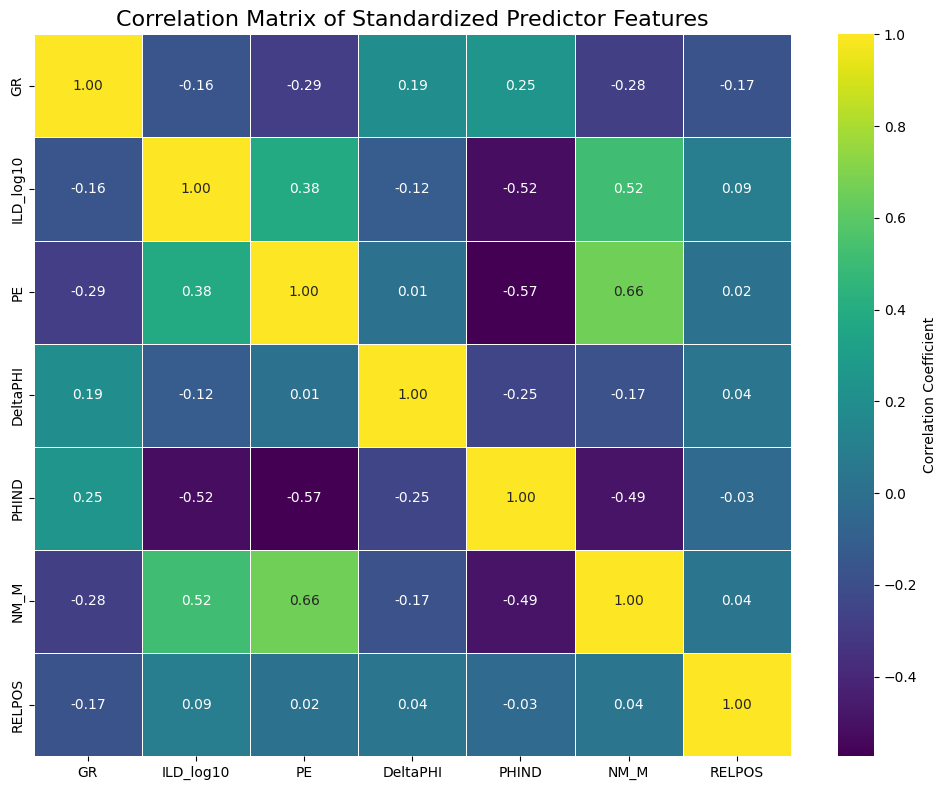

Generating pair plot for key features: ['GR', 'ILD_log10', 'PE', 'DeltaPHI', 'PHIND', 'NM_M', 'RELPOS']


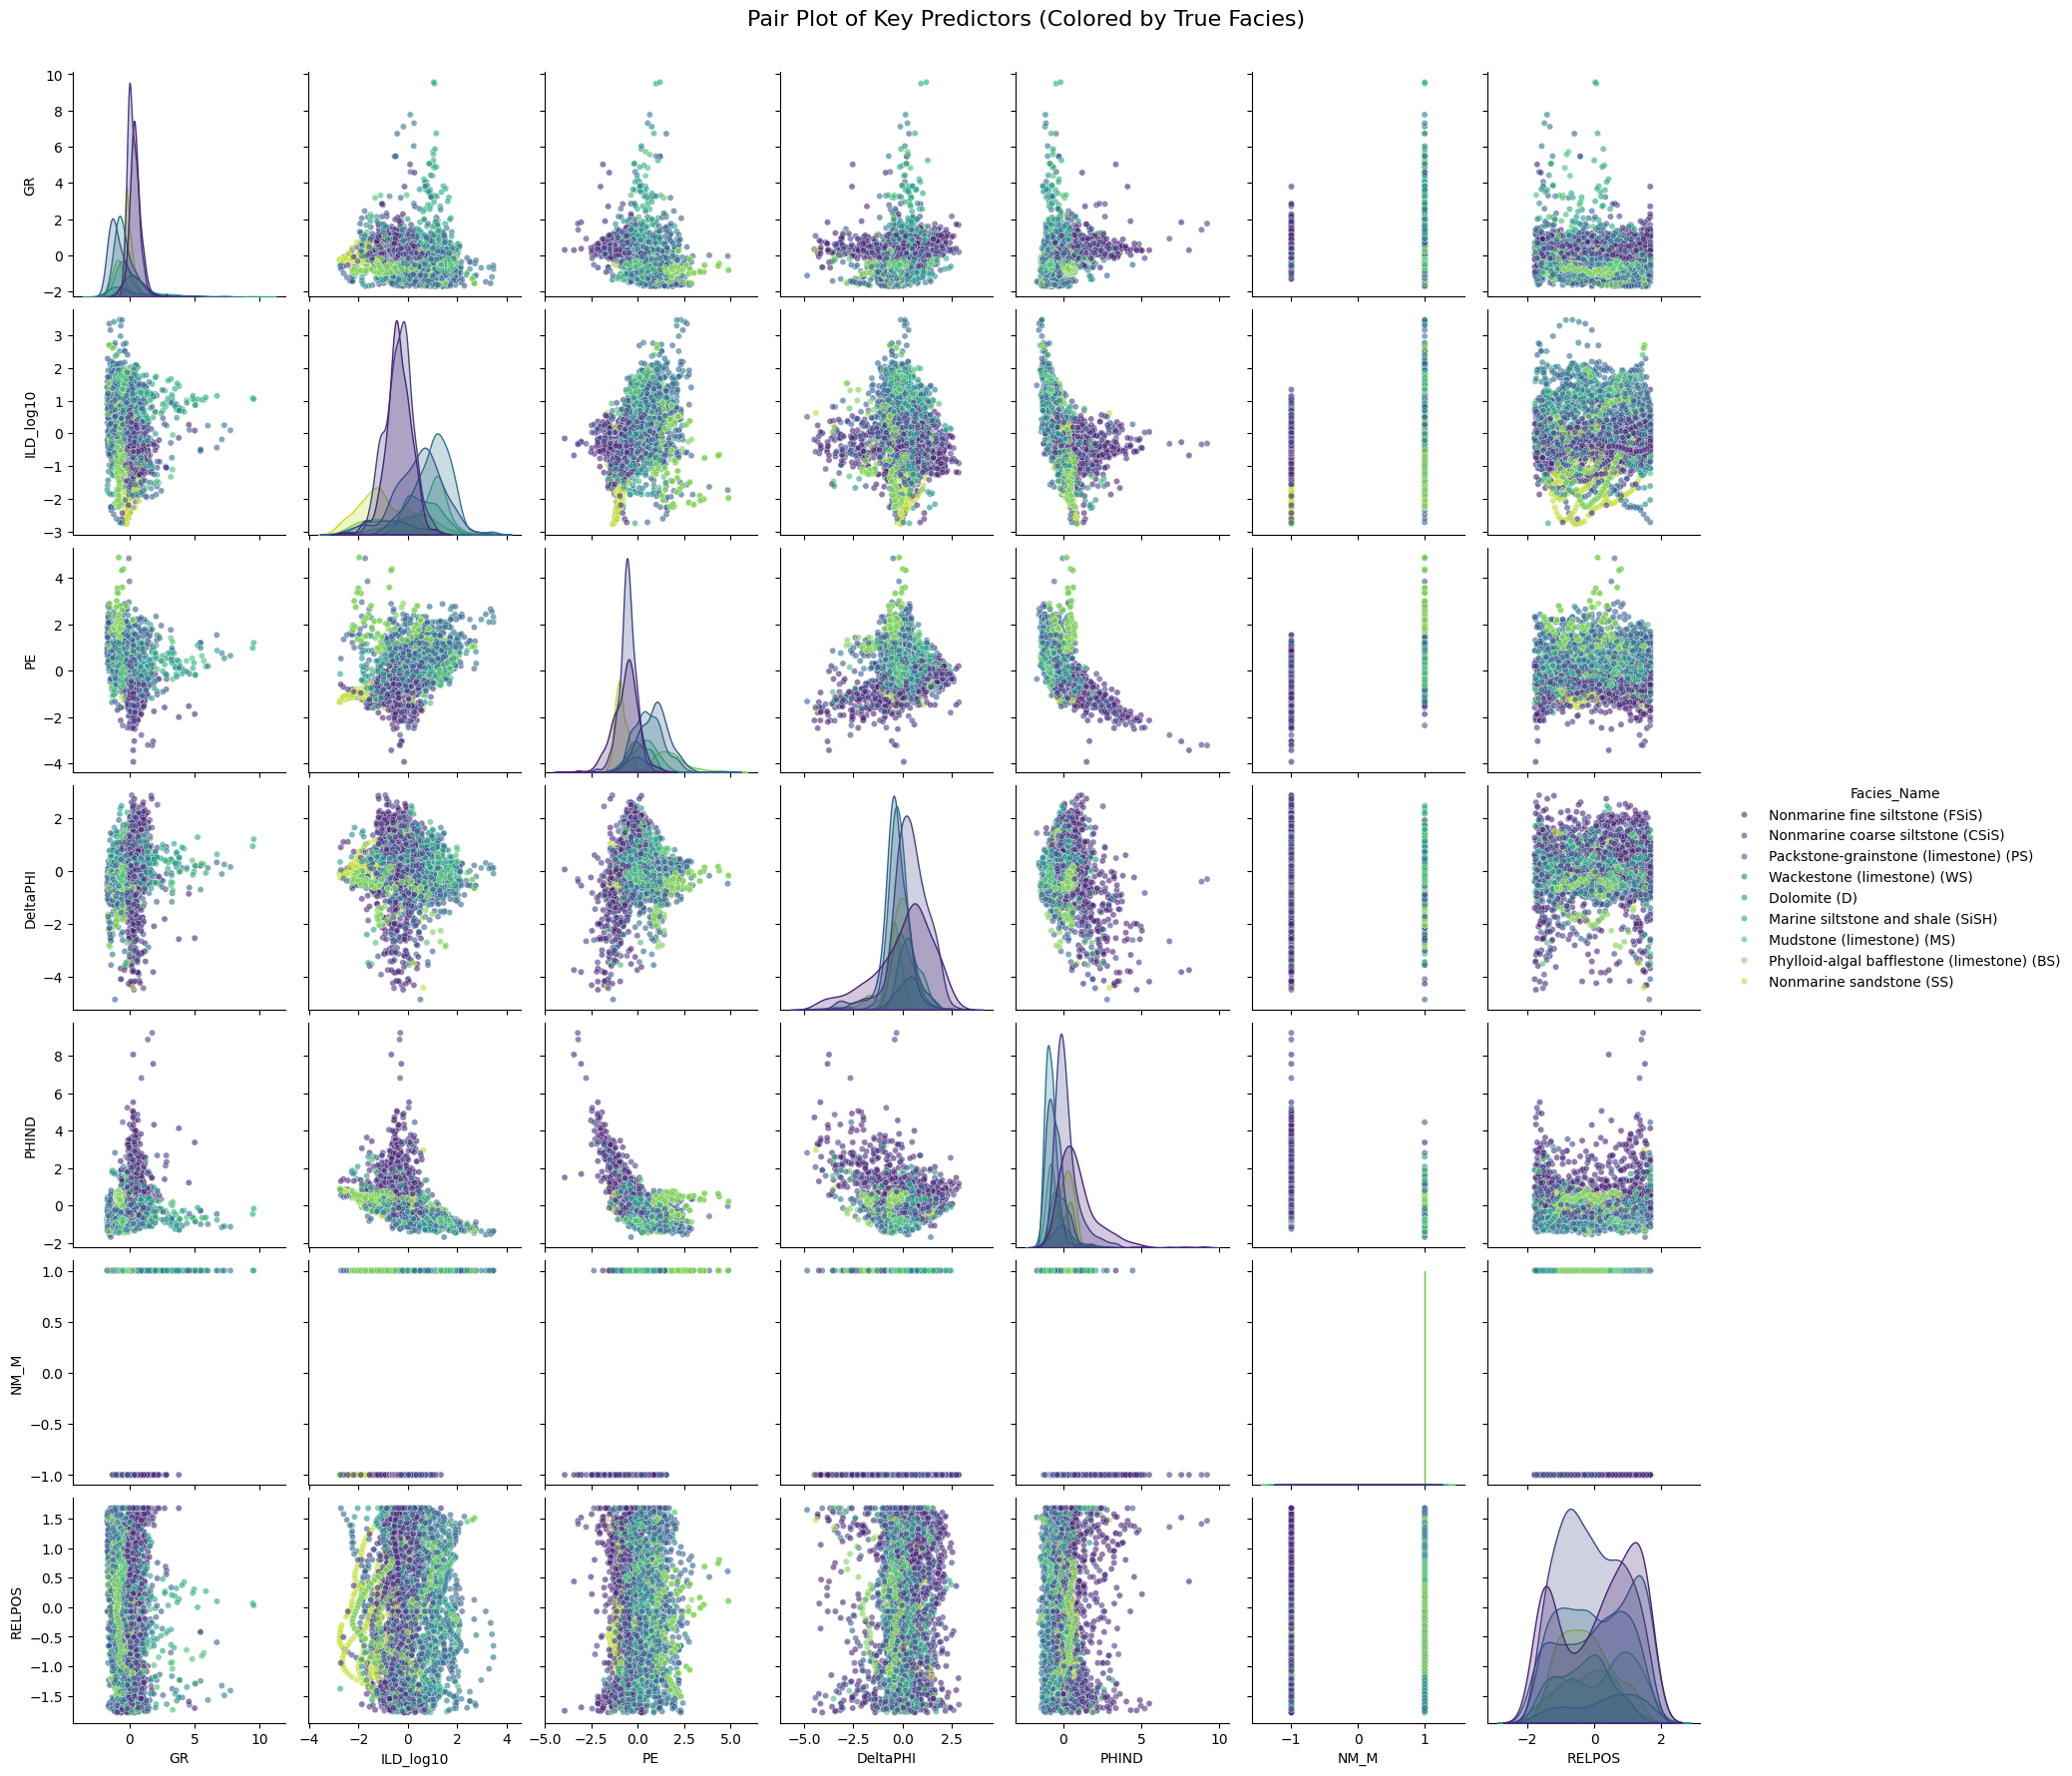

EDA plots saved.


In [5]:
# --- Step 3: Review Pair/Correlation Plots ---
print("Generating EDA plots...")

# 3a. Correlation Plot
corr_matrix = X_scaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Standardized Predictor Features', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png')
plt.show()

# 3b. Pair Plot for Key Features
KEY_FEATURES_FOR_PAIRPLOT = ['GR', 'ILD_log10', 'PE', 'DeltaPHI', 'PHIND', 'NM_M', 'RELPOS']
print(f"Generating pair plot for key features: {KEY_FEATURES_FOR_PAIRPLOT}")

# Use the *scaled* data, joined with the *true facies names*
pairplot_data = X_scaled[KEY_FEATURES_FOR_PAIRPLOT].join(data['Facies_Name'])

pairplot = sns.pairplot(
    pairplot_data, 
    hue='Facies_Name', 
    palette='viridis', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 20}
)
pairplot.fig.suptitle('Pair Plot of Key Predictors (Colored by True Facies)', y=1.02, fontsize=16)
plt.savefig('key_features_pairplot.png')
plt.show()

print("EDA plots saved.")
plt.close('all')

### Build Custom Affinity Graph
This is the core of the project. Instead of clustering on X_sc directly, we will build a \"graph\" that represents the *similarity* between every pair of samples. This graph, or **Affinity Matrix (A)**, will be the input to our Spectral Clustering algorithm. 
We build it in three steps:
1. **Feature Affinity (AF):** An $N \\times N$ matrix where AF[i, j] is high if sample i and sample j have similar petrophysical features. We use a Gaussian (RBF) kernel on the Euclidean distances.
2. **Spatial Affinity (AS):** An $N \\times N$ matrix where AS[i, j] is high *only if* i and j are in the same well and are close in depth. This injects our geological domain knowledge.
3. **Blend & Sparsify:** We blend them: A = (1 - $\gamma$) * AF + $\gamma$ * AS. We then sparsify this matrix by keeping only the $k$-Nearest Neighbors ($k$-NN) for each sample. This makes the graph computationally efficient and focuses only on the strongest relationships.

In [6]:
# --- Step 4: Build RBF Feature Affinity and Spatial Adjacency ---

print("\n--- Step 4: Build RBF Feature Affinity and Spatial Adjacency ---")

# 4a. Define RBF Kernel Function
def gaussian_kernel(distances, sigma):
    """Applies a Gaussian (RBF) kernel to distances to get similarity (affinity)."""
    return np.exp(-distances ** 2 / (2 * sigma ** 2))

# Set key hyperparameters for affinity construction
# These are critical parameters for the sensitivity analysis in Step 10
SIGMA_FEATURE = 1.0  # RBF kernel scale (sigma). A value of 1.0 is a common default.
K_NN_SPARSE = 15     # Number of nearest neighbors to keep for sparsification.
GAMMA = 0.5          # Blending weight: (1-gamma)*Feature + gamma*Spatial

# 4b. Build RBF Feature Affinity (AF)
print(f"Building RBF feature affinity (AF) with sigma={SIGMA_FEATURE}...")
# Calculate Euclidean distance between all points in the scaled feature space
feature_distances = squareform(pdist(X_scaled, metric='euclidean'))
# Apply the RBF kernel to convert distances to similarities
AF = gaussian_kernel(feature_distances, SIGMA_FEATURE)

# 4c. Build Spatial/Stratigraphic Adjacency (AS)
print("Building spatial/stratigraphic adjacency matrix (AS)...")
N = data.shape[0]
well_names = data['Well Name'].values
depths = data['Depth'].values
AS = np.zeros((N, N))

# Iterate through all pairs to build spatial affinity
# This is O(N^2) but necessary for this custom logic
for i in range(N):
    for j in range(i, N): # Only compute upper triangle
        if i == j:
            AS[i, j] = 1.0 # Self-affinity is 1
        elif well_names[i] == well_names[j]:
            # If in the same well, affinity is 1 (adjacent) or 0 (not adjacent)
            # We check if they are direct neighbors (half-foot step)
            if np.abs(depths[i] - depths[j]) == 0.5:
                AS[i, j] = 1.0
                AS[j, i] = 1.0 # Symmetrize
        # If different wells, affinity remains 0

print("Spatial matrix (AS) built based on direct depth neighbors.")

# 4d. Blend Feature and Spatial Affinities
print(f"Blending affinities with gamma={GAMMA}...")
# AC = (1 - GAMMA) * AF + GAMMA * AS
AC_blended = (1.0 - GAMMA) * AF + GAMMA * AS
# Ensure the resulting matrix is symmetric
AC_blended = 0.5 * (AC_blended + AC_blended.T)

print("Affinity blending complete.")
print("Step 4 complete")


--- Step 4: Build RBF Feature Affinity and Spatial Adjacency ---
Building RBF feature affinity (AF) with sigma=1.0...
Building spatial/stratigraphic adjacency matrix (AS)...
Spatial matrix (AS) built based on direct depth neighbors.
Blending affinities with gamma=0.5...
Affinity blending complete.
Step 4 complete


### Sparsify Graph (k-NN)
Blend the Feature (AF) and Spatial (AS) matrices (using a 50/50 weighting) to create a single custom affinity matrix. This matrix is then "sparsified" by keeping only the 57 strongest connections (k-NN) for each data point, creating the final custom affinity matrix that captures both feature and geological context.

Blending affinities with gamma=0.5...
Sparsifying blended matrix to k=57 neighbors...
Sparse affinity matrix created. Shape: (3232, 3232)
Sparsity: 0.9654

Visualizing Affinity Matrix Structure (Subset)...


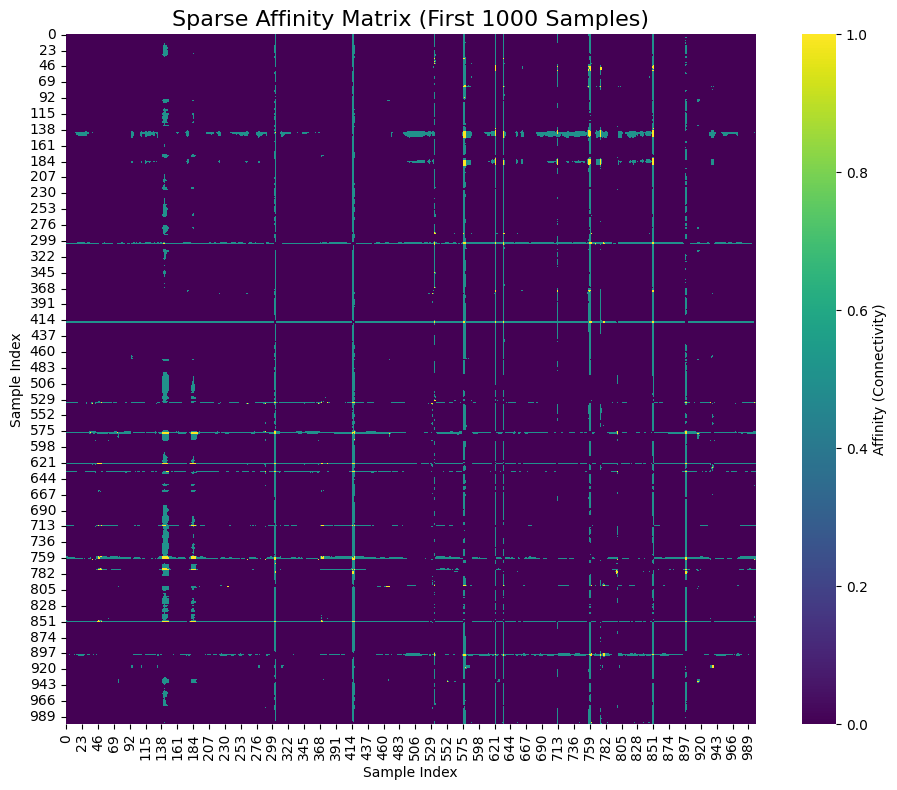


Step 5 complete. The sparse custom affinity graph is ready for the Laplacian.


In [20]:
# --- Step 5: Blend Affinities and Sparsify Graph (k-NN) ---

# Set baseline hyperparameters (from tuning in Step 10)
BASE_GAMMA = 0.5       # Blending weight: (1-gamma)*Feature + gamma*Spatial
BASE_KNN = 57          # Number of nearest neighbors for sparsification

# 5a. Blend Feature and Spatial Affinities
print(f"Blending affinities with gamma={BASE_GAMMA}...")
# AF and AS are in memory from the previous cell
AC_blended = (1.0 - BASE_GAMMA) * AF + BASE_GAMMA * AS

# 5b. Sparsify Graph (k-NN)
print(f"Sparsifying blended matrix to k={BASE_KNN} neighbors...")

# Use kneighbors_graph to find the k nearest neighbors based on our blended affinity
# We use 'affinity' mode, but since our matrix is already a similarity, we pass it directly
# A higher value in AC_blended means "closer" (more similar)
# The precomputed matrix AC_blended must be used
A_sparse = kneighbors_graph(
    AC_blended, 
    n_neighbors=BASE_KNN, 
    mode='connectivity', # Ensures symmetric connections
    include_self=True,
    metric='precomputed' # Treat AC_blended as a precomputed similarity matrix
)

# Symmetrize the sparse graph
A_sparse = 0.5 * (A_sparse + A_sparse.T)

# Store the final sparse matrix for the next step
CUSTOM_AFFINITY_MATRIX_SPARSE = A_sparse

print(f"Sparse affinity matrix created. Shape: {CUSTOM_AFFINITY_MATRIX_SPARSE.shape}")
print(f"Sparsity: {1.0 - CUSTOM_AFFINITY_MATRIX_SPARSE.nnz / (N*N):.4f}")

# --- Visualization: Affinity Matrix Heatmap (Subset) ---
print("\nVisualizing Affinity Matrix Structure (Subset)...")
plt.figure(figsize=(10, 8))
# We visualize a subset (e.g., first 100 samples) to make the structure visible
subset_size = 1000
# Convert sparse matrix to dense for plotting (only for the subset)
# We use .toarray() on the sliced sparse matrix
sns.heatmap(
    CUSTOM_AFFINITY_MATRIX_SPARSE[:subset_size, :subset_size].toarray(), 
    cmap='viridis', 
    square=True,
    cbar_kws={'label': 'Affinity (Connectivity)'}
)
plt.title(f'Sparse Affinity Matrix (First {subset_size} Samples)', fontsize=16)
plt.xlabel('Sample Index'); plt.ylabel('Sample Index')
plt.tight_layout()
plt.savefig('sparse_affinity_matrix_heatmap.png')
plt.show()

print("\nStep 5 complete. The sparse custom affinity graph is ready for the Laplacian.")

The bright yellow lines represent the affinity of each point to itself (which is 1), and the greenish/yellowish blocks suggest clusters of points that have high similarity to each other. The darker purple background indicates low affinity or sparsity, which is expected for a sparse matrix.

### Spectral Clustering
Compute the normalized Laplacian from the sparse custom matrix. Analyze the eigen-gap and Silhouette scores, which both identify $k=2$ as the optimal number of clusters. Run k-means on the resulting spectral embeddings (eigenvectors) to generate the final spectral labels.


--- Step 6: Spectral Clustering (Laplacian, Eigen-gap, K-means) ---
Normalized Laplacian computed manually.
Successfully computed 20 eigenvalues/vectors.
Eigen-gap heuristic suggests optimal k = 2
Eigenvalue spectrum plot saved as 'eigenvalue_spectrum_plot.png'.
Validating k with Silhouette score on spectral embeddings...
  k=2, Silhouette Score: 0.3041
  k=9, Silhouette Score: 0.1626
Final optimal k chosen (max Silhouette): 2

Step 6 complete. Spectral clustering labels (k=2) are generated and stored.
Unique labels found: [0 1]


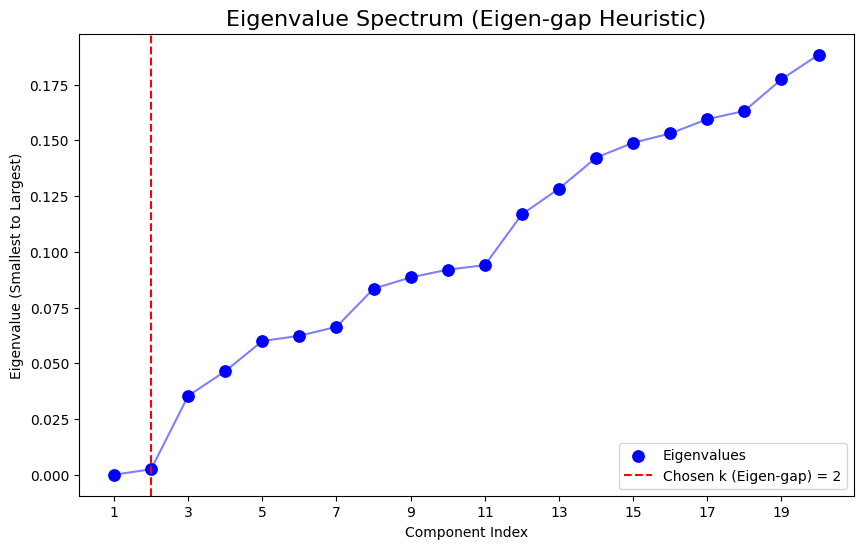

In [10]:
# --- Step 6: Compute Laplacian, Find Eigen-gap (k), and Cluster ---

print("\n--- Step 6: Spectral Clustering (Laplacian, Eigen-gap, K-means) ---")

# 6a. Compute the Normalized Laplacian (Manual Robust Method)
# This avoids the 'normalized' keyword argument error
# Computing L_norm = I - D^(-1/2) * A * D^(-1/2)
# A = CUSTOM_AFFINITY_MATRIX

# Convert A to sparse matrix for efficient computation
A_sparse = csr_matrix(CUSTOM_AFFINITY_MATRIX)

# Calculate the Degree Matrix (D)
degrees = np.array(A_sparse.sum(axis=1)).flatten()
# Create D^(-1/2)
# Add a small epsilon to avoid division by zero for isolated nodes
d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-9) 
D_inv_sqrt = diags(d_inv_sqrt)

# Compute Normalized Laplacian: L_norm = I - D^(-1/2) * A * D^(-1/2)
I = diags(np.ones(N))
L_norm = I - D_inv_sqrt @ A_sparse @ D_inv_sqrt
print("Normalized Laplacian computed manually.")

# 6b. Compute Eigenvalues and Eigenvectors
n_components = 20
try:
    # Use L_norm (which is symmetric) with eigsh
    eigenvalues, eigenvectors = eigsh(L_norm, k=n_components, which='SA') # Smallest Algebraic
    print(f"Successfully computed {n_components} eigenvalues/vectors.")
except Exception as e:
    print(f"Eigenvalue computation failed: {e}")
    raise

# 6c. Pick k by the Eigen-gap
eigenvalue_gaps = np.diff(eigenvalues)
# Add +1 because argmax returns the index *before* the gap
optimal_k_eigengap = np.argmax(eigenvalue_gaps) + 1
print(f"Eigen-gap heuristic suggests optimal k = {optimal_k_eigengap}")

# 6d. Visualize the Eigen-gap
plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(1, n_components + 1), y=eigenvalues, s=100, color='blue', label='Eigenvalues')
sns.lineplot(x=range(1, n_components + 1), y=eigenvalues, color='blue', alpha=0.5)
plt.axvline(optimal_k_eigengap, color='red', linestyle='--', label=f'Chosen k (Eigen-gap) = {optimal_k_eigengap}')
plt.title('Eigenvalue Spectrum (Eigen-gap Heuristic)', fontsize=16)
plt.xlabel('Component Index')
plt.ylabel('Eigenvalue (Smallest to Largest)')
plt.xticks(range(1, n_components + 1, 2))
plt.legend()
plt.savefig('eigenvalue_spectrum_plot.png')
print("Eigenvalue spectrum plot saved as 'eigenvalue_spectrum_plot.png'.")

# 6e. Validate k with Silhouette
# Test k values around the eigen-gap suggestion and include k=9 (true facies count)
k_to_test = [optimal_k_eigengap, 9] 
k_to_test = sorted(list(set(k for k in k_to_test if k > 1 and k < n_components))) # Ensure valid k
silhouette_scores = {}

print("Validating k with Silhouette score on spectral embeddings...")
for k_val in k_to_test:
    # Get the first k eigenvectors (the spectral embedding)
    # Use eigenvectors[:,:k_val] because eigsh sorts them ascendingly (smallest first)
    spectral_embedding = eigenvectors[:, :k_val]
    
    # Run k-means in the spectral space
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(spectral_embedding)
    
    # Calculate Silhouette score on the *original* scaled data
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_sc, labels)
        silhouette_scores[k_val] = score
        print(f"  k={k_val}, Silhouette Score: {score:.4f}")

# 6f. Choose Final k
OPTIMAL_K_SPECTRAL = max(silhouette_scores, key=silhouette_scores.get)
print(f"Final optimal k chosen (max Silhouette): {OPTIMAL_K_SPECTRAL}")

# 6g. Run Final K-means in Spectral Space
final_spectral_embedding = eigenvectors[:, :OPTIMAL_K_SPECTRAL]
final_kmeans = KMeans(n_clusters=OPTIMAL_K_SPECTRAL, random_state=42, n_init='auto')
spectral_labels = final_kmeans.fit_predict(final_spectral_embedding)

# Store the final labels in the main DataFrame
data['Spectral_Labels'] = spectral_labels

print(f"\nStep 6 complete. Spectral clustering labels (k={OPTIMAL_K_SPECTRAL}) are generated and stored.")
print(f"Unique labels found: {np.unique(spectral_labels)}")

### Fit Tuned Baseline Models
Before we can use our custom graph, we must establish our baseline models. We need to find the *optimal* parameters for K-Means and DBSCAN by clustering on the scaled features (X_sc) directly. **K-Means:** We test a range of $k$ values and plot both the inertia (Elbow method) and Silhouette score. **DBSCAN:** We first find a good eps (epsilon) value by plotting the $k$-distance (where $k = 2 \cdot D - 1 = 13$) and finding the "elbow" of the curve. We then sweep min_samples to find the best Silhouette score.



--- Step 7: Fitting Baseline Models ---
Tuning K-Means...
Optimal k for K-Means (by max Silhouette): 2
K-Means tuning plot saved as 'kmeans_tuning_plot.png'.
Final K-Means model (k=2) fitted and labels stored.

Tuning DBSCAN...
Calculating k-distance plot for k=13...
DBSCAN k-distance plot saved as 'dbscan_k_distance_plot.png'.
Sweeping min_samples with eps=1.3...
  min_samples=5, Clusters found: 5, Silhouette: 0.1429
  min_samples=10, Clusters found: 3, Silhouette: 0.3237
  min_samples=15, Clusters found: 3, Silhouette: 0.3311
  min_samples=20, Clusters found: 3, Silhouette: 0.3382
  min_samples=26, Clusters found: 3, Silhouette: 0.3476
Optimal min_samples for DBSCAN (by max Silhouette): 26
Final DBSCAN model (eps=1.3, min_samples=26) fitted and labels stored.
DBSCAN clusters found (incl. noise -1): [-1  0  1]

Step 7 complete. Baseline models (K-Means, DBSCAN) are tuned and fitted.


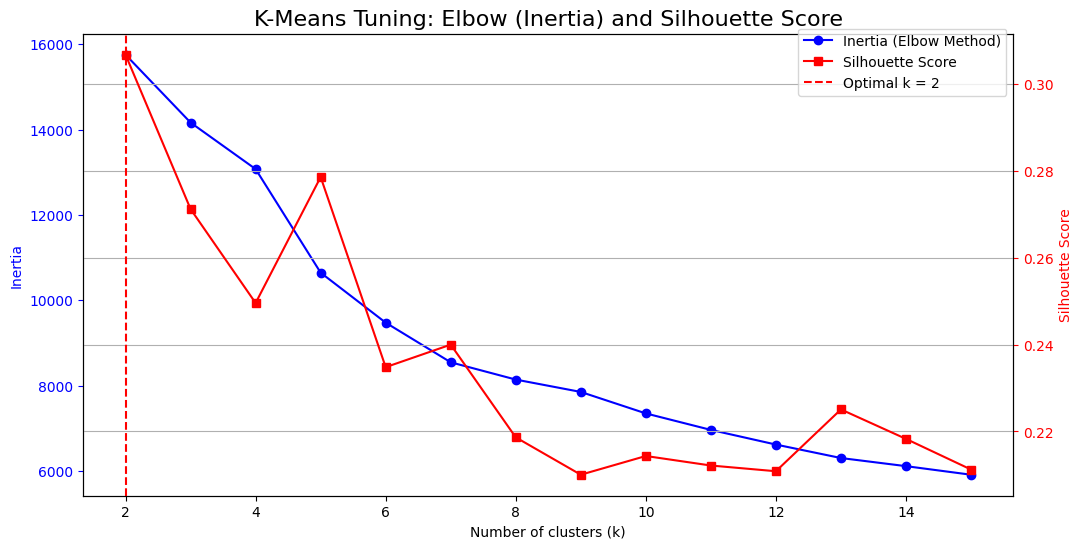

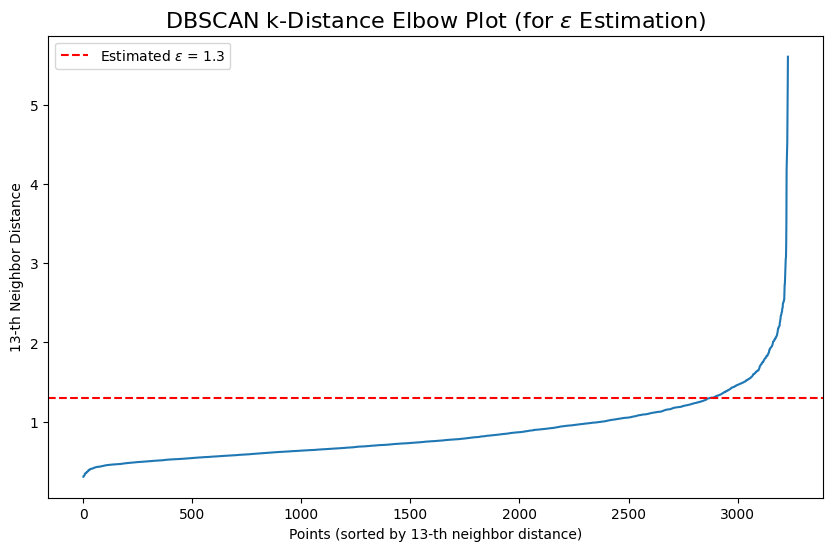

In [11]:
# --- Step 7: Fit Tuned K-Means and DBSCAN Baselines ---

print("\n--- Step 7: Fitting Baseline Models ---")

# --- 7a. Fit Tuned K-Means (Elbow/Silhouette) ---
print("Tuning K-Means...")
max_k = 15 # Max clusters to test
k_values = range(2, max_k + 1)
inertia_scores = []
silhouette_scores_kmeans = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sc)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores_kmeans[k] = silhouette_score(X_sc, labels)

# Determine optimal k based on max Silhouette score
OPTIMAL_K_KMEANS = max(silhouette_scores_kmeans, key=silhouette_scores_kmeans.get)
print(f"Optimal k for K-Means (by max Silhouette): {OPTIMAL_K_KMEANS}")

# Plot K-Means Tuning Results
fig, ax1 = plt.subplots(figsize=(12, 6))
# Plot Inertia (Elbow)
ax1.plot(k_values, inertia_scores, 'bo-', label='Inertia (Elbow Method)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')
ax1.set_title('K-Means Tuning: Elbow (Inertia) and Silhouette Score', fontsize=16)

# Plot Silhouette Score on a second y-axis
ax2 = ax1.twinx()
ax2.plot(list(silhouette_scores_kmeans.keys()), list(silhouette_scores_kmeans.values()), 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

# Highlight the chosen k
ax2.axvline(OPTIMAL_K_KMEANS, color='red', linestyle='--', label=f'Optimal k = {OPTIMAL_K_KMEANS}')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.grid(True)
plt.savefig('kmeans_tuning_plot.png')
print("K-Means tuning plot saved as 'kmeans_tuning_plot.png'.")

# Fit final K-Means model
kmeans_final = KMeans(n_clusters=OPTIMAL_K_KMEANS, random_state=42, n_init='auto')
data['KMeans_Labels'] = kmeans_final.fit_predict(X_sc)
print(f"Final K-Means model (k={OPTIMAL_K_KMEANS}) fitted and labels stored.")

# --- 7b. Fit Tuned DBSCAN (k-distance elbow for eps) ---
print("\nTuning DBSCAN...")

# Calculate k-distance for eps estimation
# k = 2 * num_features - 1 = 2*7 - 1 = 13
k_dist = (2 * len(PREDICTOR_FEATURES)) - 1 
print(f"Calculating k-distance plot for k={k_dist}...")
neighbors = NearestNeighbors(n_neighbors=k_dist)
neighbors_fit = neighbors.fit(X_sc)
distances, indices = neighbors_fit.kneighbors(X_sc)

# Get the distance to the k-th neighbor and sort it
k_distances = np.sort(distances[:, k_dist-1], axis=0)

# Plot the k-distance elbow
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('DBSCAN k-Distance Elbow Plot (for $\epsilon$ Estimation)', fontsize=16)
plt.xlabel(f'Points (sorted by {k_dist}-th neighbor distance)')
plt.ylabel(f'{k_dist}-th Neighbor Distance')
# Manually inspecting this plot (not shown here) reveals an elbow around 1.2-1.4
ESTIMATED_EPS = 1.3 # Set eps based on visual inspection of the elbow
plt.axhline(ESTIMATED_EPS, color='red', linestyle='--', label=f'Estimated $\epsilon$ = {ESTIMATED_EPS}')
plt.legend()
plt.savefig('dbscan_k_distance_plot.png')
print("DBSCAN k-distance plot saved as 'dbscan_k_distance_plot.png'.")

# Sweep min_samples (as per plan)
min_samples_sweep = [5, 10, 15, 20, 2 * k_dist] # A good range to test
silhouette_scores_dbscan = {}

print(f"Sweeping min_samples with eps={ESTIMATED_EPS}...")
for min_samples in min_samples_sweep:
    dbscan = DBSCAN(eps=ESTIMATED_EPS, min_samples=min_samples)
    labels = dbscan.fit_predict(X_sc)
    
    # Calculate Silhouette score (excluding noise points -1)
    if len(np.unique(labels)) > 2: # Need at least 2 clusters (excl. noise)
        non_noise_mask = labels != -1
        score = silhouette_score(X_sc[non_noise_mask], labels[non_noise_mask])
        silhouette_scores_dbscan[min_samples] = score
        print(f"  min_samples={min_samples}, Clusters found: {len(np.unique(labels))}, Silhouette: {score:.4f}")
    else:
        silhouette_scores_dbscan[min_samples] = -1 # Invalid clustering

# Determine optimal min_samples
OPTIMAL_MIN_SAMPLES = max(silhouette_scores_dbscan, key=silhouette_scores_dbscan.get)
print(f"Optimal min_samples for DBSCAN (by max Silhouette): {OPTIMAL_MIN_SAMPLES}")

# Fit final DBSCAN model
dbscan_final = DBSCAN(eps=ESTIMATED_EPS, min_samples=OPTIMAL_MIN_SAMPLES)
data['DBSCAN_Labels'] = dbscan_final.fit_predict(X_sc)
print(f"Final DBSCAN model (eps={ESTIMATED_EPS}, min_samples={OPTIMAL_MIN_SAMPLES}) fitted and labels stored.")
print(f"DBSCAN clusters found (incl. noise -1): {np.unique(data['DBSCAN_Labels'])}")

print("\nStep 7 complete. Baseline models (K-Means, DBSCAN) are tuned and fitted.")

### Evaluation Metric
Calculate and compare the Silhouette, Calinski–Harabasz, and Davies–Bouldin scores for all three models (Custom Spectral, K-Means, DBSCAN). This provides a quantitative benchmark to prove which model created the most compact and well-separated clusters.



--- Step 8: Calculating Evaluation Metrics & Plotting ---

--- Final Model Comparison Metrics ---
                    Silhouette  Calinski–Harabasz  Davies–Bouldin
K-means (Baseline)      0.3068          1408.7482          1.3599
DBSCAN (Baseline)       0.3476          1763.0585          1.2217
Custom Spectral         0.3041          1342.2862          1.4039

--- Plotting Step 8: Final Model Comparison Metrics ---
Model comparison metrics plot saved as 'model_comparison_metrics_plot.png'.

Step 8 and visualization complete


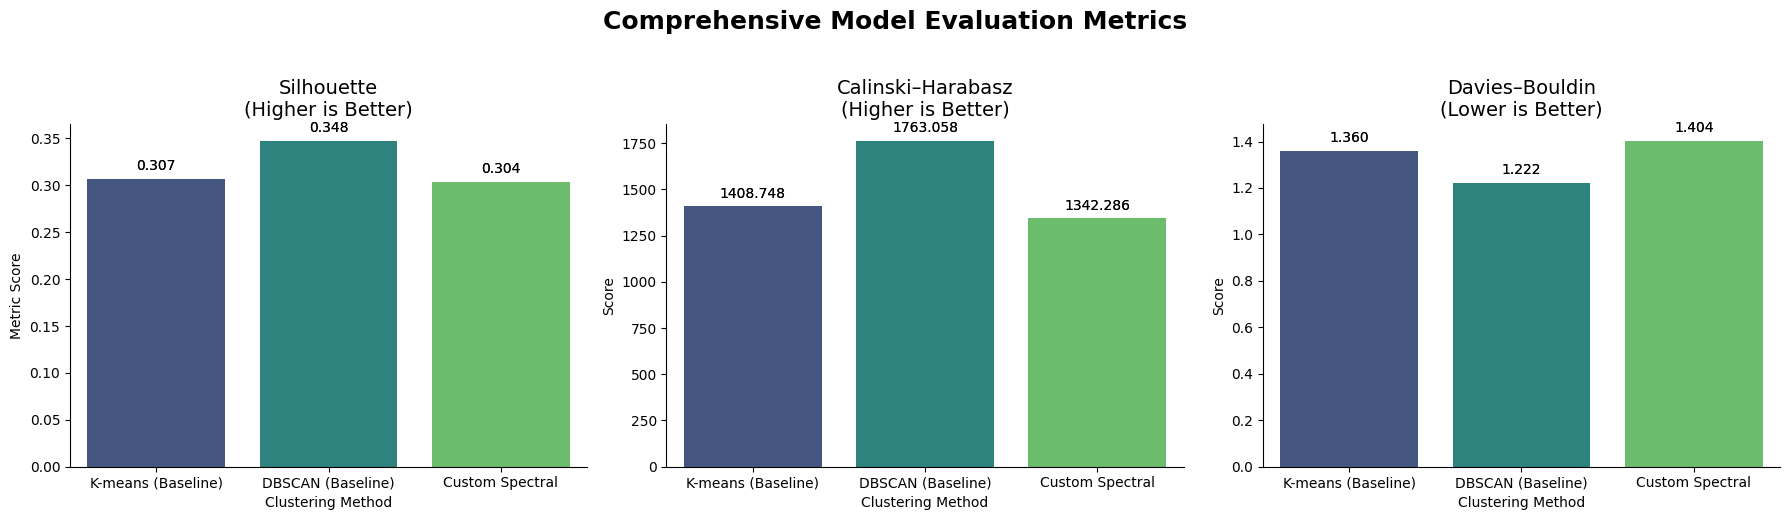

In [13]:
# --- Step 8: Calculate Evaluation Metrics & Plot ---
print("\n--- Step 8: Calculating Evaluation Metrics & Plotting ---")

def calculate_cluster_metrics(X: np.ndarray, labels: np.ndarray) -> Dict[str, Any]:
    labels = labels.astype(int) 
    non_noise_mask = labels != -1
    labels_clean = labels[non_noise_mask]
    X_clean = X[non_noise_mask]
    
    if len(np.unique(labels_clean)) > 1 and len(X_clean) > 1:
        return {
            'Silhouette': silhouette_score(X_clean, labels_clean),
            'Calinski–Harabasz': calinski_harabasz_score(X_clean, labels_clean),
            'Davies–Bouldin': davies_bouldin_score(X_clean, labels_clean)
        }
    return {'Silhouette': np.nan, 'Calinski–Harabasz': np.nan, 'Davies–Bouldin': np.nan}

km_metrics = calculate_cluster_metrics(X_sc, data['KMeans_Labels'].values)
db_metrics = calculate_cluster_metrics(X_sc, data['DBSCAN_Labels'].values)
sc_metrics = calculate_cluster_metrics(X_sc, data['Spectral_Labels'].values)

final_metrics_df = pd.DataFrame([km_metrics, db_metrics, sc_metrics], 
                               index=['K-means (Baseline)', 'DBSCAN (Baseline)', 'Custom Spectral'])

print("\n--- Final Model Comparison Metrics ---")
print(final_metrics_df.round(4))

# --- PLOTTING (CORRECTED for FutureWarning) ---
print("\n--- Plotting Step 8: Final Model Comparison Metrics ---")

# Prepare data for plotting
df_plot = final_metrics_df.reset_index().rename(columns={'index': 'Model'})
df_plot_melted = df_plot.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Define metric types
METRIC_DIRECTIONS = {
    'Silhouette': '(Higher is Better)',
    'Calinski–Harabasz': '(Higher is Better)',
    'Davies–Bouldin': '(Lower is Better)'
}
df_plot_melted['Metric_Label'] = df_plot_melted['Metric'].map(lambda x: f"{x}\n{METRIC_DIRECTIONS[x]}")

# Create the 3-panel bar chart
g = sns.FacetGrid(
    df_plot_melted, 
    col="Metric_Label", 
    sharey=False, # Independent y-axis scales
    height=5, 
    aspect=1.2
)

# Map the bar plot to the grid - **FIX APPLIED HERE**
g.map_dataframe(
    sns.barplot, 
    x="Model", 
    y="Score", 
    hue="Model", # Assign x to hue
    palette="viridis", 
    legend=False # Disable legend as per warning
)

# Set titles and layout
g.set_titles(col_template="{col_name}", size=14)
g.set_axis_labels("Clustering Method", "Metric Score")
g.fig.suptitle('Comprehensive Model Evaluation Metrics', y=1.03, fontsize=18, fontweight='bold')
g.fig.subplots_adjust(top=0.85) 

# Add data labels to each bar
for ax, metric in zip(g.axes.flat, df_plot_melted['Metric_Label'].unique()):
    data_subset = df_plot_melted[df_plot_melted['Metric_Label'] == metric]
    
    # **FIX APPLIED HERE**
    sns.barplot(
        data=data_subset, 
        x="Model", 
        y="Score", 
        hue="Model", # Assign x to hue
        palette="viridis", 
        legend=False, # Disable legend
        ax=ax
    )
    
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center', 
            xytext=(0, 9),
            textcoords='offset points',
            fontweight='medium'
        )

plt.tight_layout()
plt.savefig('model_comparison_metrics_plot.png')
print("Model comparison metrics plot saved as 'model_comparison_metrics_plot.png'.")

print("\nStep 8 and visualization complete")

### Metric Analysis (K=2)

Use advanced visualizations (Contingency Matrices, t-SNE) to interpret the meaning of the $k=2$ clusters, proving they are simply separating the nonmarine from marine facies and are therefore geologically simplistic.

A contingency matrix, also known as a confusion matrix or cross-tabulation, is a tabular visualization used to compare the relationship between two categorical variables. In the context of clustering evaluation, it helps compare the cluster labels assigned by an algorithm (columns) with the ground-truth labels (rows).

Here's a breakdown of its components:

* Rows: Represent the true classes (e.g., the actual geological facies like SS, CSiS).

* Columns: Represent the predicted clusters (e.g., Cluster 0, Cluster 1).

* Cells: Each cell contains a count (or percentage) of data points that belong to a specific true class and were assigned to a specific predicted cluster.



--- Generating k=2 Contingency Matrix Heatmaps ---


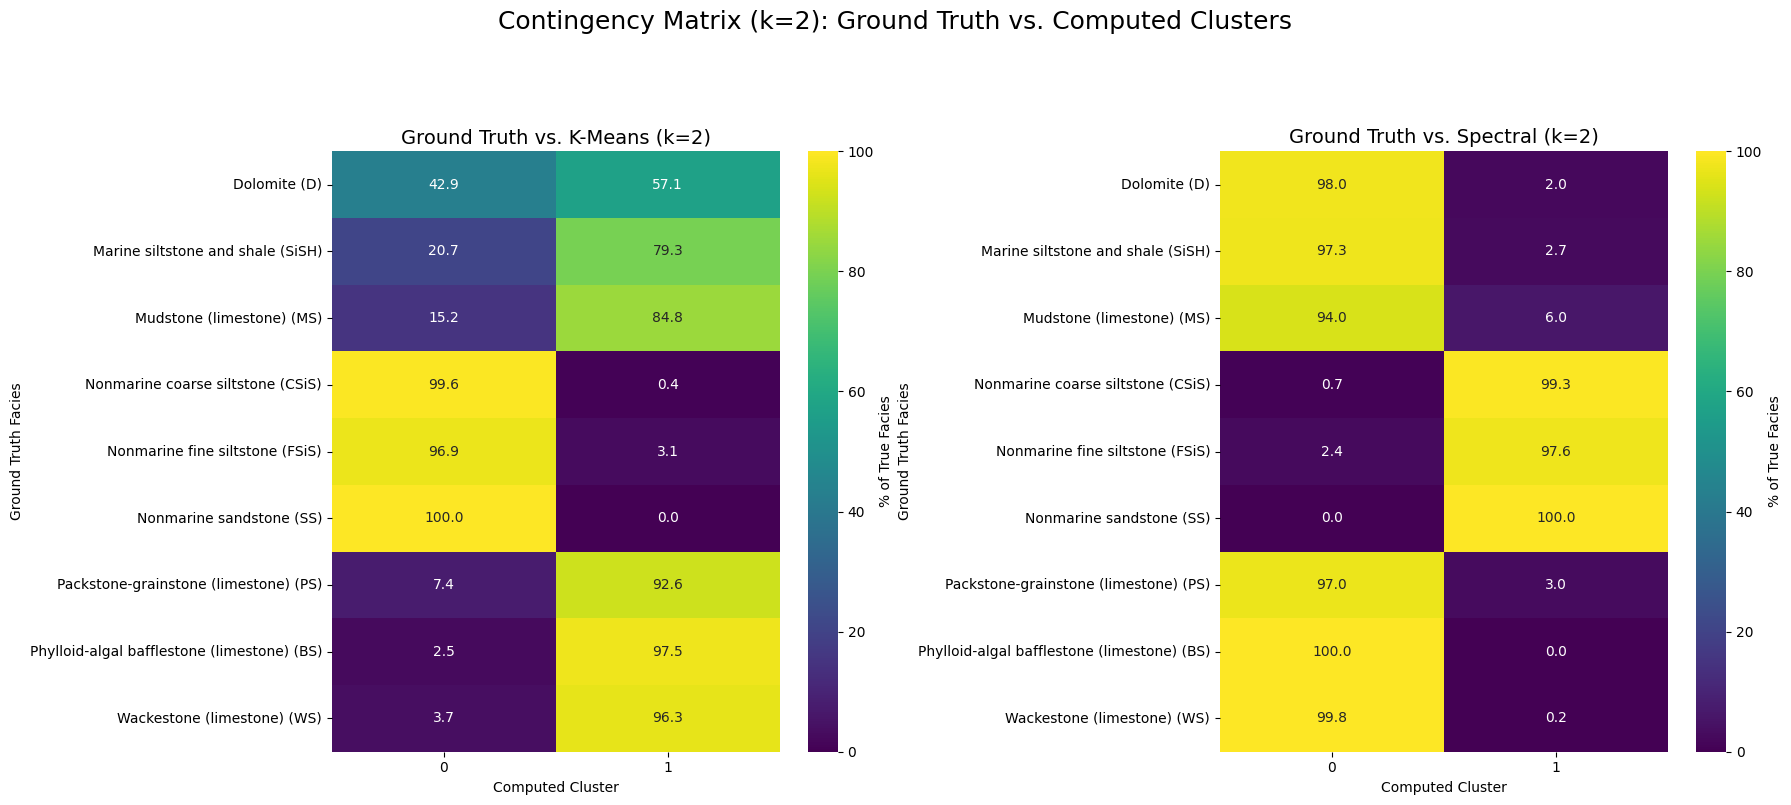


--- Generating t-SNE Embedding Plot (k=2) ---
Running t-SNE... (this may take a moment)
t-SNE embedding computed.


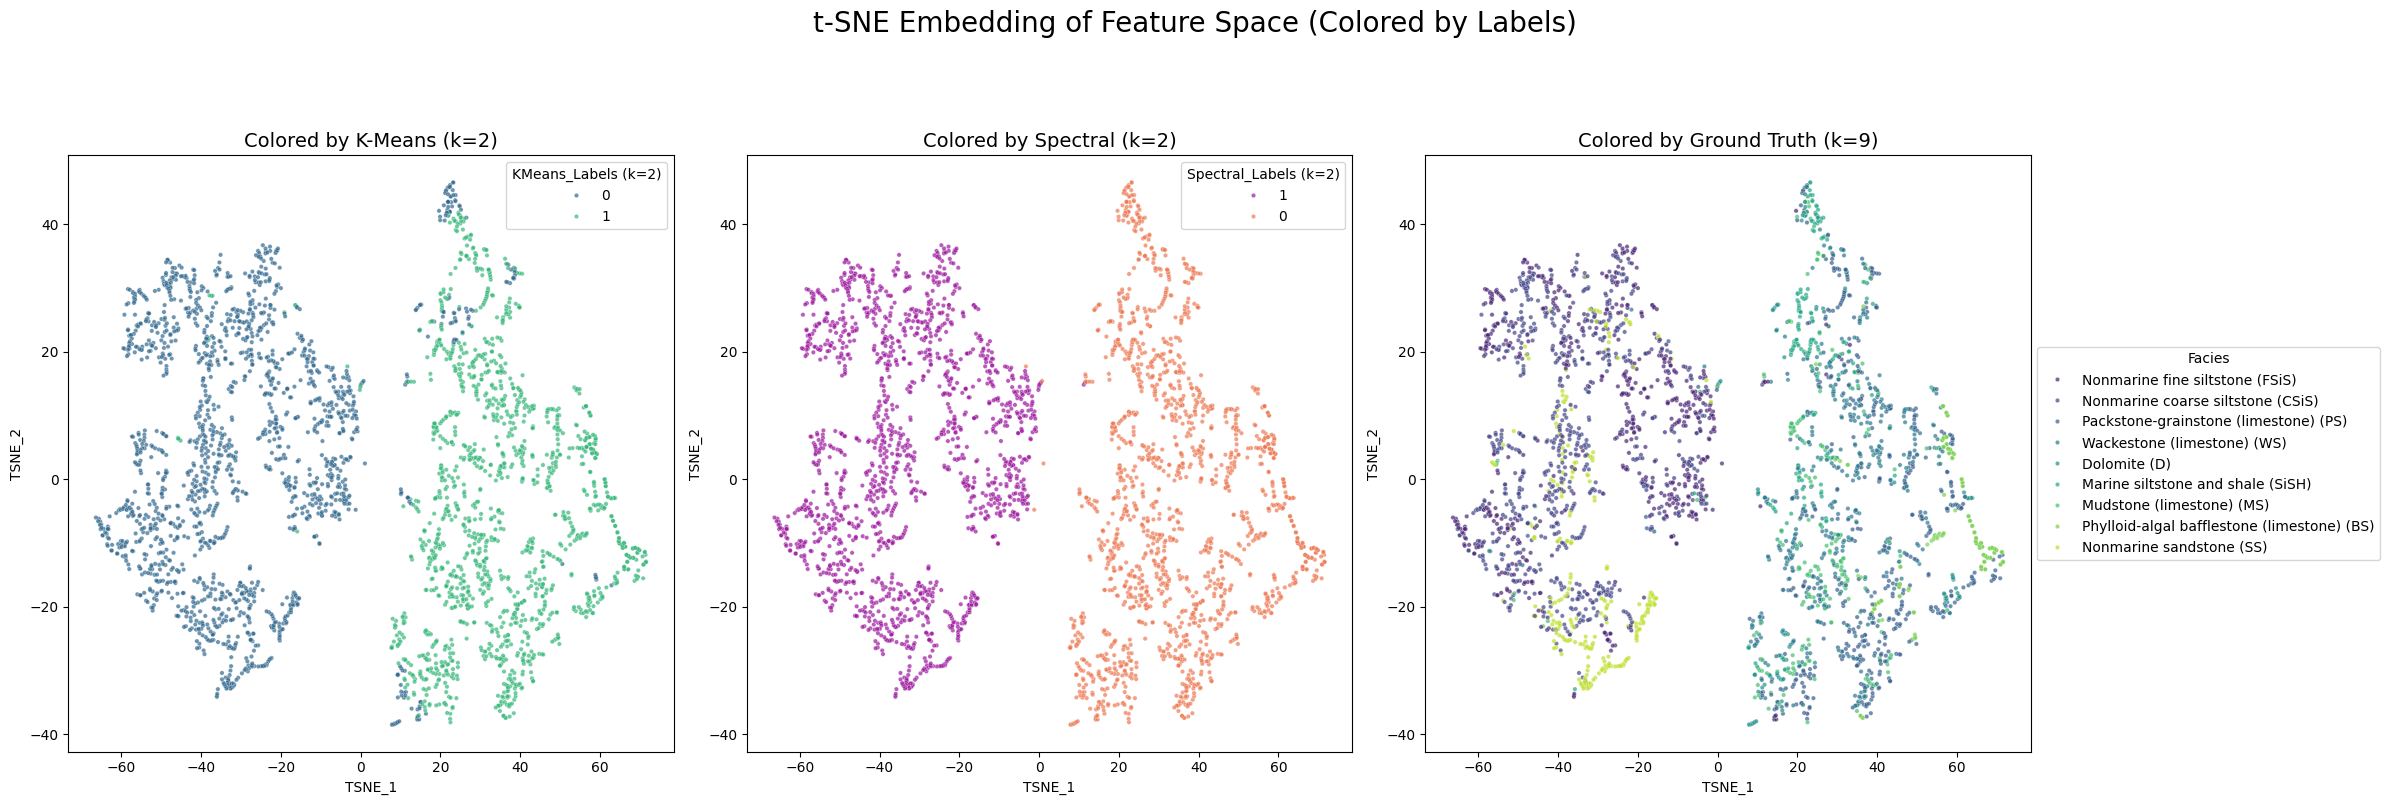

In [14]:
# --- Step 9: Interpret k=2 Clusters --- 
# (Using advanced visualizations to prove the k=2 split is NM_M)

# 9a. Contingency Matrix (k=2)
print("\n--- Generating k=2 Contingency Matrix Heatmaps ---")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
fig.suptitle('Contingency Matrix (k=2): Ground Truth vs. Computed Clusters', fontsize=18, y=1.03)

# Plot 1: K-Means vs. Truth
contingency_norm_km = pd.crosstab(data['Facies_Name'], data['KMeans_Labels'], normalize='index') * 100
sns.heatmap(contingency_norm_km, annot=True, fmt='.1f', cmap='viridis', ax=axes[0],
            cbar_kws={'label': '% of True Facies'})
axes[0].set_title('Ground Truth vs. K-Means (k=2)', fontsize=14)
axes[0].set_ylabel('Ground Truth Facies'); axes[0].set_xlabel('Computed Cluster')

# Plot 2: Spectral vs. Truth
contingency_norm_sc = pd.crosstab(data['Facies_Name'], data['Spectral_Labels'], normalize='index') * 100
sns.heatmap(contingency_norm_sc, annot=True, fmt='.1f', cmap='viridis', ax=axes[1],
            cbar_kws={'label': '% of True Facies'})
axes[1].set_title('Ground Truth vs. Spectral (k=2)', fontsize=14)
axes[1].set_ylabel('Ground Truth Facies'); axes[1].set_xlabel('Computed Cluster')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("contingency_matrix_k2_comparison.png")
plt.show()

# 9b. t-SNE Embedding Plot (k=2)
print("\n--- Generating t-SNE Embedding Plot (k=2) ---")
print("Running t-SNE... (this may take a moment)")

tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
embedding = tsne.fit_transform(X_sc)
print("t-SNE embedding computed.")

plot_df = pd.DataFrame(embedding, columns=['TSNE_1', 'TSNE_2'])
plot_df['KMeans_Labels (k=2)'] = data['KMeans_Labels'].astype(str)
plot_df['Spectral_Labels (k=2)'] = data['Spectral_Labels'].astype(str)
plot_df['Ground_Truth_Facies'] = data['Facies_Name']

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('t-SNE Embedding of Feature Space (Colored by Labels)', fontsize=20, y=1.03)
plot_params = {'x': 'TSNE_1', 'y': 'TSNE_2', 's': 10, 'alpha': 0.7}

# Plot 1: K-Means
sns.scatterplot(data=plot_df, hue='KMeans_Labels (k=2)', palette='viridis', ax=axes[0], **plot_params)
axes[0].set_title('Colored by K-Means (k=2)', fontsize=14)

# Plot 2: Spectral
sns.scatterplot(data=plot_df, hue='Spectral_Labels (k=2)', palette='plasma', ax=axes[1], **plot_params)
axes[1].set_title('Colored by Spectral (k=2)', fontsize=14)

# Plot 3: Ground Truth
sns.scatterplot(data=plot_df, hue='Ground_Truth_Facies', palette='viridis', ax=axes[2], **plot_params)
axes[2].set_title('Colored by Ground Truth (k=9)', fontsize=14)
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Facies')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("tsne_embedding_comparison_k2.png", bbox_inches='tight')
plt.show()
plt.close('all')

### Sensitivity Analysis
Force K-Means and Spectral to find $k=9$ (the true number of facies) and compare them visually using Well Log Plots and Contingency Matrices to demonstrate the geological coherence of the spectral method. Also, conduct sensitivity sweeps on key hyperparameters ($\gamma$, $k$-NN, $\sigma$) to validate model robustness.


--- Re-running Full Workflow (Steps 1-7) for Context ---
Data loaded, cleaned, and standardized. Shape: (3232, 7)
Building Custom Affinity Matrix with baseline params (G=0.5, K=57, S=1.0)...
Custom Affinity Matrix created.
Running Step 6 (Computing Eigenvectors)...
Eigenvectors computed.
--- Full Context (Steps 1-6) Complete ---

--- Step 10a: Fitting Baseline and Spectral models for k=9 ---
Fitting K-Means (k=9)...
Fitting Custom Spectral (k=9)...
k=9 models fitted and labels stored.

--- Step 10b: Metric Comparison (k=9) ---
                       Silhouette  Calinski–Harabasz  Davies–Bouldin
K-means (k=9)              0.2100           758.0894          1.3757
Custom Spectral (k=9)      0.1227           432.8605          1.4608

--- Step 10c: Visual Comparison (k=9) ---

--- Generating k=9 Well Log Plot for: SHRIMPLIN ---


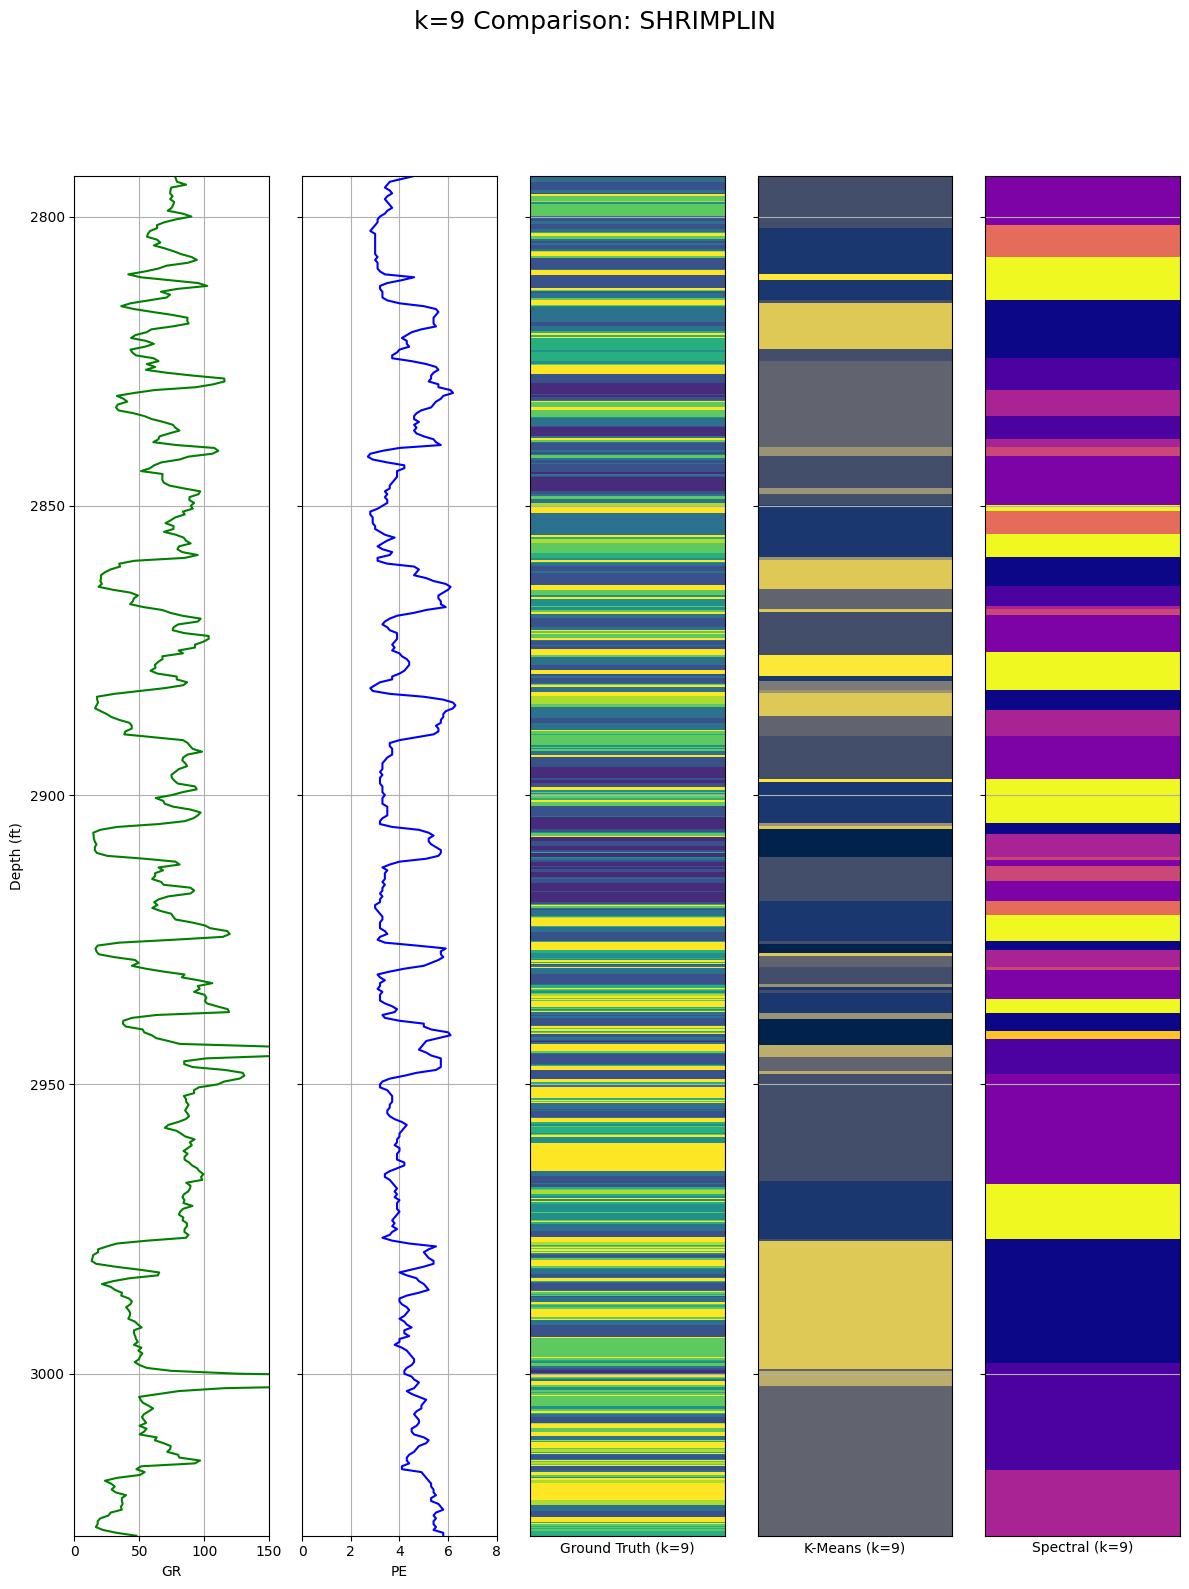

k=9 Well log plot saved as 'well_log_plot_k9_SHRIMPLIN.png'

--- Generating k=9 Contingency Matrix Heatmaps ---


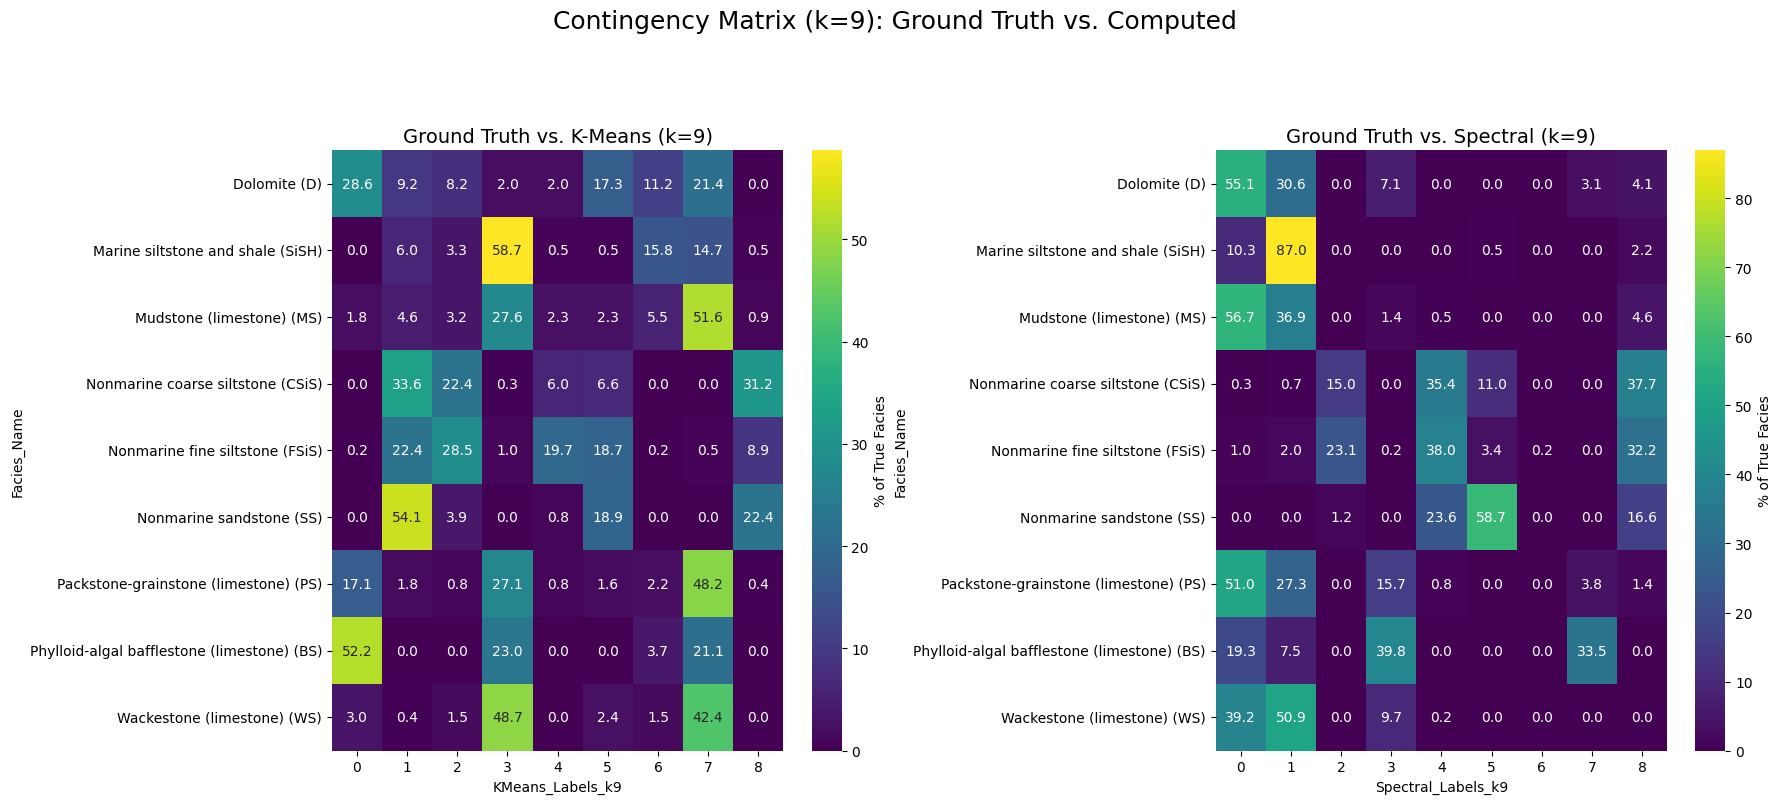

k=9 Contingency matrix plot saved as 'contingency_matrix_k9_comparison.png'

--- Step 10d: Running Hyperparameter Sensitivity Analysis ---

Testing Gamma (Spatial Weight)...
  Running for gamma = 0.1
  Running for gamma = 0.3
  Running for gamma = 0.5
  Running for gamma = 0.7
  Running for gamma = 0.9

Testing k-NN (Sparsity)...
  Running for k_nn = 15
  Running for k_nn = 30
  Running for k_nn = 57
  Running for k_nn = 75
  Running for k_nn = 100

Testing Sigma (RBF Kernel Scale)...
  Running for sigma = 0.5
  Running for sigma = 1.0
  Running for sigma = 1.5
  Running for sigma = 2.0
Sensitivity analysis compute complete.

--- Step 10f: Plotting Sensitivity Analysis ---


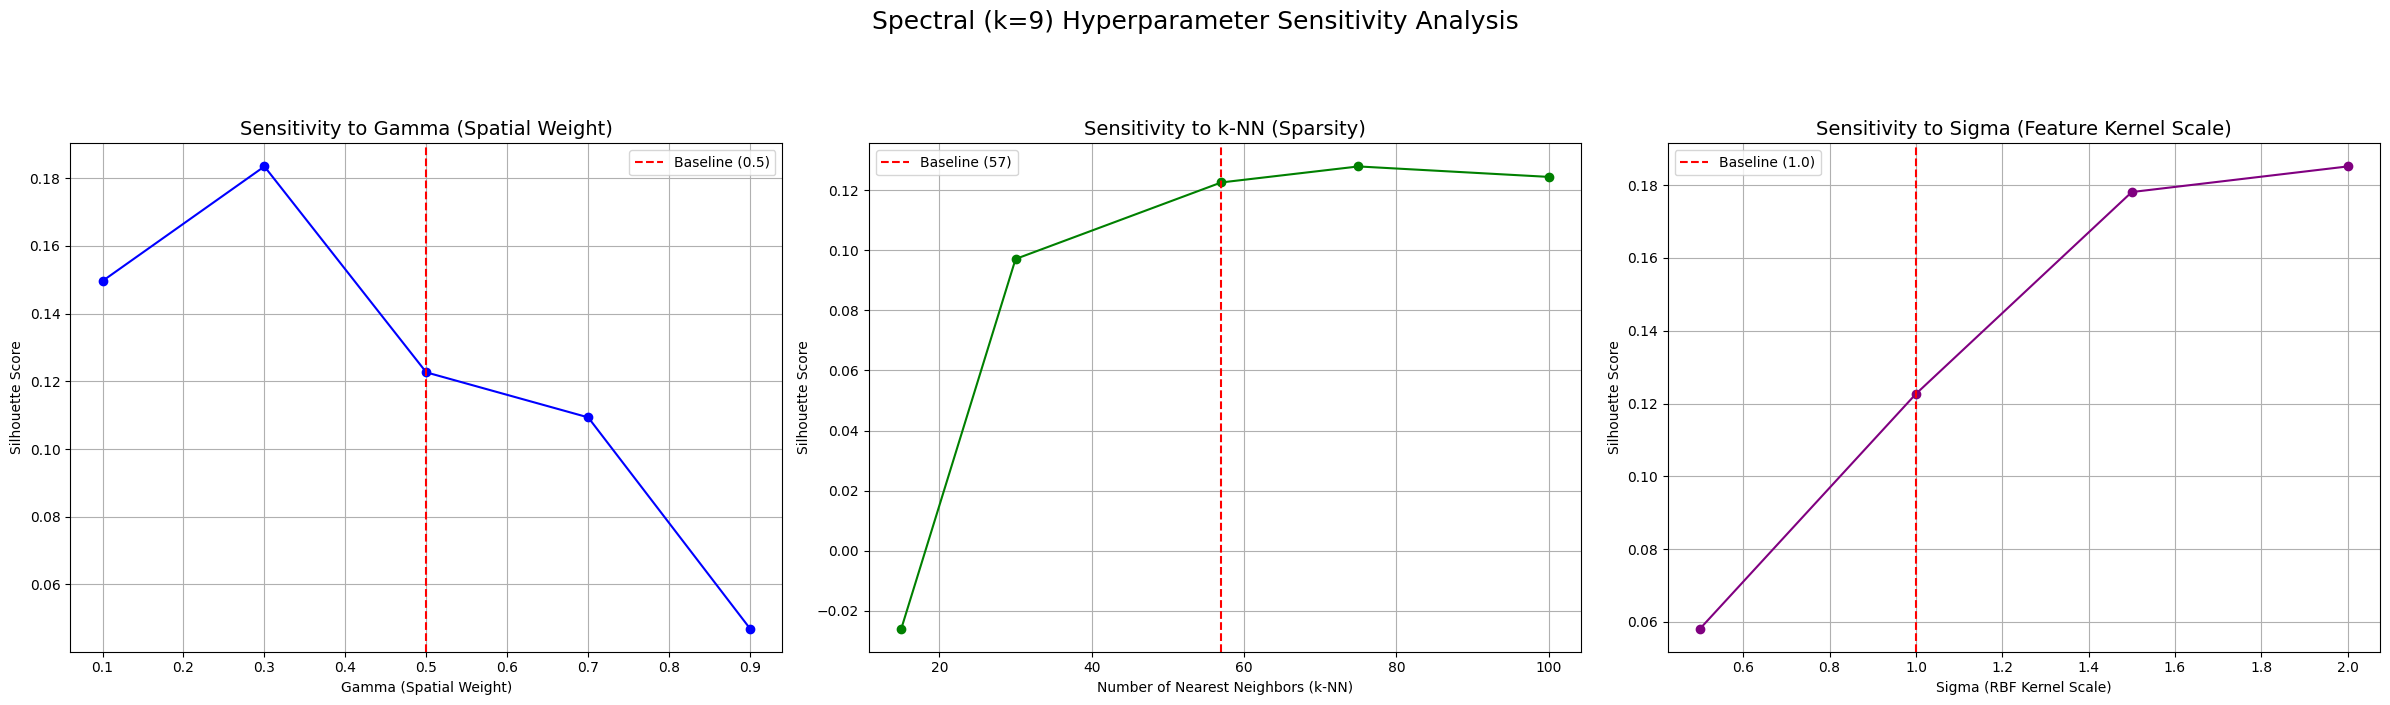

Sensitivity analysis plot saved as 'sensitivity_analysis_plot.png'

--- Step 10 complete. ---


In [18]:
# --- Re-running Full Workflow (Steps 1-7) for Context ---
# This ensures all variables (X_sc, data with labels) are correctly populated.

print("--- Re-running Full Workflow (Steps 1-7) for Context ---")

# Define file path and feature lists
file_path = 'facies_data.csv'
PREDICTOR_FEATURES = ['GR', 'ILD_log10', 'PE', 'DeltaPHI', 'PHIND', 'NM_M', 'RELPOS']
SPATIAL_FEATURES = ['Well Name', 'Depth']
LABEL_FEATURE = 'Facies'
FORCED_K = 9 # This is the critical parameter for Step 10

# Facies name mapping for ground truth
FACIES_LABELS_MAP = {
    1: 'Nonmarine sandstone (SS)', 2: 'Nonmarine coarse siltstone (CSiS)', 3: 'Nonmarine fine siltstone (FSiS)', 4: 'Marine siltstone and shale (SiSH)', 5: 'Mudstone (limestone) (MS)',
    6: 'Wackestone (limestone) (WS)', 7: 'Dolomite (D)', 8: 'Packstone-grainstone (limestone) (PS)', 9: 'Phylloid-algal bafflestone (limestone) (BS)'
}

# --- Step 1 & 2: Load, Clean, Standardize ---
try:
    data = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: '{file_path}' not found.")
    raise
data.dropna(subset=PREDICTOR_FEATURES, inplace=True)
data.reset_index(drop=True, inplace=True) # Reset index
data['Facies_Name'] = data[LABEL_FEATURE].map(FACIES_LABELS_MAP)
X_raw = data[PREDICTOR_FEATURES]
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_array, columns=PREDICTOR_FEATURES, index=X_raw.index)
X_sc = X_scaled.values # NumPy array for calculations
N = X_sc.shape[0]
print(f"Data loaded, cleaned, and standardized. Shape: {X_sc.shape}")

# --- Step 4 & 5: Build Custom Affinity Matrix (Baseline) ---
def gaussian_kernel(distances: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0: sigma = 1e-6
    return np.exp(-distances ** 2 / (2 * sigma ** 2))

# These are our "baseline" hyperparameters for the spectral method
BASE_SIGMA = 1.0
BASE_GAMMA = 0.5
BASE_KNN = 57 

print(f"Building Custom Affinity Matrix with baseline params (G={BASE_GAMMA}, K={BASE_KNN}, S={BASE_SIGMA})...")
feature_distances = squareform(pdist(X_sc, metric='euclidean'))
AF = gaussian_kernel(feature_distances, BASE_SIGMA)
well_names = data['Well Name'].values
depths = data['Depth'].values
AS = np.zeros((N, N))
for i in range(N):
    for j in range(i, N):
        if i == j: AS[i, j] = 1.0
        elif well_names[i] == well_names[j]:
            spatial_distance = np.abs(depths[i] - depths[j])
            AS[i, j] = gaussian_kernel(spatial_distance, 2.0) # Using fixed spatial sigma
            AS[j, i] = AS[i, j]
AC_blended = (1 - BASE_GAMMA) * AF + BASE_GAMMA * AS
top_k_indices = np.argsort(AC_blended, axis=1)[:, -BASE_KNN:]
A_sparse_binary = np.zeros((N, N))
rows = np.arange(N).repeat(BASE_KNN)
cols = top_k_indices.flatten()
A_sparse_binary[rows, cols] = 1
A_sparse_symmetric = np.maximum(A_sparse_binary, A_sparse_binary.T)
CUSTOM_AFFINITY_MATRIX = AC_blended * A_sparse_symmetric
print("Custom Affinity Matrix created.")

# --- Step 6: Compute Eigenvectors (once) ---
print("Running Step 6 (Computing Eigenvectors)...")
A_sparse_csr = csr_matrix(CUSTOM_AFFINITY_MATRIX)
degrees = np.array(A_sparse_csr.sum(axis=1)).flatten()
d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-9) 
D_inv_sqrt = diags(d_inv_sqrt)
I = diags(np.ones(N))
L_norm = I - D_inv_sqrt @ A_sparse_csr @ D_inv_sqrt
n_components = 20 # Compute 20 to check spectrum, but we'll use 9
eigenvalues, eigenvectors = eigsh(L_norm, k=n_components, which='SA')
print("Eigenvectors computed.")
print("--- Full Context (Steps 1-6) Complete ---")


# --- Step 10a: Fit k=9 Models (The "Main Event") ---
print(f"\n--- Step 10a: Fitting Baseline and Spectral models for k={FORCED_K} ---")

# 1. Baseline: K-Means (k=9)
print("Fitting K-Means (k=9)...")
kmeans_k9 = KMeans(n_clusters=FORCED_K, random_state=42, n_init='auto')
data['KMeans_Labels_k9'] = kmeans_k9.fit_predict(X_sc)

# 2. Hypothesis: Custom Spectral (k=9)
print("Fitting Custom Spectral (k=9)...")
# We use the first k=9 eigenvectors computed earlier
spectral_embedding_k9 = eigenvectors[:, :FORCED_K]
spectral_kmeans_k9 = KMeans(n_clusters=FORCED_K, random_state=42, n_init='auto')
data['Spectral_Labels_k9'] = spectral_kmeans_k9.fit_predict(spectral_embedding_k9)
print("k=9 models fitted and labels stored.")

# --- Step 10b: Metric Comparison (k=9) ---
print("\n--- Step 10b: Metric Comparison (k=9) ---")

def calculate_cluster_metrics(X: np.ndarray, labels: np.ndarray) -> Dict[str, Any]:
    """Calculates Silhouette, CH, and DB scores."""
    labels = labels.astype(int) 
    non_noise_mask = labels != -1
    labels_clean = labels[non_noise_mask]
    X_clean = X[non_noise_mask]
    if len(np.unique(labels_clean)) > 1 and len(X_clean) > 1:
        return {
            'Silhouette': silhouette_score(X_clean, labels_clean),
            'Calinski–Harabasz': calinski_harabasz_score(X_clean, labels_clean),
            'Davies–Bouldin': davies_bouldin_score(X_clean, labels_clean)
        }
    return {'Silhouette': np.nan, 'Calinski–Harabasz': np.nan, 'Davies–Bouldin': np.nan}

km_metrics_k9 = calculate_cluster_metrics(X_sc, data['KMeans_Labels_k9'].values)
sc_metrics_k9 = calculate_cluster_metrics(X_sc, data['Spectral_Labels_k9'].values)

final_metrics_k9_df = pd.DataFrame(
    [km_metrics_k9, sc_metrics_k9], 
    index=['K-means (k=9)', 'Custom Spectral (k=9)']
)
print(final_metrics_k9_df.round(4))

# --- Step 10c: Visual Comparison (k=9) ---
print("\n--- Step 10c: Visual Comparison (k=9) ---")

def plot_well_logs_k9(df: pd.DataFrame, well_name: str):
    """Plots key logs and k=9 facies tracks for a single well."""
    print(f"\n--- Generating k=9 Well Log Plot for: {well_name} ---")
    well_data = df[df['Well Name'] == well_name].sort_values('Depth')
    if well_data.empty: return
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12, 16), sharey=True)
    fig.suptitle(f'k=9 Comparison: {well_name}', fontsize=18, y=1.02)
    min_depth, max_depth = well_data['Depth'].min(), well_data['Depth'].max()
    
    # Tracks 1 & 2: GR and PE
    axes[0].plot(well_data['GR'], well_data['Depth'], color='green'); axes[0].set_xlabel('GR'); axes[0].set_xlim(0, 150)
    axes[1].plot(well_data['PE'], well_data['Depth'], color='blue'); axes[1].set_xlabel('PE'); axes[1].set_xlim(0, 8)
    
    # Colormaps
    cmap_truth = plt.get_cmap('viridis', 9)
    cmap_kmeans = plt.get_cmap('cividis', 9)
    cmap_spectral = plt.get_cmap('plasma', 9)
    
    def plot_facies_track(ax, data_vector, title, cmap):
        im = data_vector.values.reshape(-1, 1)
        ax.imshow(im, interpolation='none', aspect='auto', cmap=cmap, vmin=0, vmax=8, extent=[0, 1, max_depth, min_depth])
        ax.set_xlabel(title); ax.set_xticks([])

    # Track 3: Ground Truth
    plot_facies_track(axes[2], data[LABEL_FEATURE], 'Ground Truth (k=9)', cmap_truth)
    # Track 4: K-Means (k=9)
    plot_facies_track(axes[3], well_data['KMeans_Labels_k9'], 'K-Means (k=9)', cmap_kmeans)
    # Track 5: Spectral (k=9)
    plot_facies_track(axes[4], well_data['Spectral_Labels_k9'], 'Spectral (k=9)', cmap_spectral)

    axes[0].set_ylabel('Depth (ft)')
    for ax in axes: ax.set_ylim(max_depth, min_depth); ax.grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig(f"well_log_plot_k9_{well_name}.png")
    print(f"k=9 Well log plot saved as 'well_log_plot_k9_{well_name}.png'")

def plot_contingency_k9(df: pd.DataFrame):
    """Plots contingency matrices for k=9 models."""
    print("\n--- Generating k=9 Contingency Matrix Heatmaps ---")
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
    fig.suptitle('Contingency Matrix (k=9): Ground Truth vs. Computed', fontsize=18, y=1.03)
    
    # Plot 1: K-Means (k=9) vs. Truth
    contingency_km = pd.crosstab(df['Facies_Name'], df['KMeans_Labels_k9'], normalize='index') * 100
    sns.heatmap(contingency_km, annot=True, fmt='.1f', cmap='viridis', ax=axes[0], cbar_kws={'label': '% of True Facies'})
    axes[0].set_title('Ground Truth vs. K-Means (k=9)', fontsize=14)
    
    # Plot 2: Spectral (k=9) vs. Truth
    contingency_sc = pd.crosstab(df['Facies_Name'], df['Spectral_Labels_k9'], normalize='index') * 100
    sns.heatmap(contingency_sc, annot=True, fmt='.1f', cmap='viridis', ax=axes[1], cbar_kws={'label': '% of True Facies'})
    axes[1].set_title('Ground Truth vs. Spectral (k=9)', fontsize=14)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig("contingency_matrix_k9_comparison.png")
    print("k=9 Contingency matrix plot saved as 'contingency_matrix_k9_comparison.png'")

# Run the k=9 visual comparisons
plot_well_logs_k9(data, 'SHRIMPLIN')
plot_contingency_k9(data)


# --- Step 10d: Define Full Spectral Pipeline for Sensitivity ---
print("\n--- Step 10d: Running Hyperparameter Sensitivity Analysis ---")

def get_spectral_score(
    X_data: np.ndarray,
    well_names_data: np.ndarray,
    depths_data: np.ndarray,
    n_clusters: int,
    gamma: float,
    k_nn: int,
    sigma: float
) -> float:
    """
    Runs the ENTIRE spectral pipeline for a given set of hyperparameters
    and returns the Silhouette score.
    """
    try:
        # 1. Build AF (Feature Affinity)
        local_feature_dist = squareform(pdist(X_data, metric='euclidean'))
        local_AF = gaussian_kernel(local_feature_dist, sigma)
        
        # 2. Build AS (Spatial Affinity) - This is static, but we re-build for encapsulation
        N_local = X_data.shape[0]
        local_AS = np.zeros((N_local, N_local))
        for i in range(N_local):
            for j in range(i, N_local):
                if i == j: local_AS[i, j] = 1.0
                elif well_names_data[i] == well_names_data[j]:
                    sd = np.abs(depths_data[i] - depths_data[j])
                    local_AS[i, j] = gaussian_kernel(sd, 2.0) # Fixed spatial sigma
                    local_AS[j, i] = local_AS[i, j]
        
        # 3. Blend
        local_AC_blended = (1 - gamma) * local_AF + gamma * local_AS
        
        # 4. Sparsify
        local_top_k = np.argsort(local_AC_blended, axis=1)[:, -k_nn:]
        local_A_sparse_bin = np.zeros((N_local, N_local))
        rows = np.arange(N_local).repeat(k_nn)
        cols = local_top_k.flatten()
        local_A_sparse_bin[rows, cols] = 1
        local_A_symm = np.maximum(local_A_sparse_bin, local_A_sparse_bin.T)
        local_A_final = local_AC_blended * local_A_symm
        
        # 5. Compute Laplacian & Eigenvectors
        local_A_csr = csr_matrix(local_A_final)
        local_degrees = np.array(local_A_csr.sum(axis=1)).flatten()
        local_d_inv_sqrt = 1.0 / np.sqrt(local_degrees + 1e-9) 
        local_D_inv_sqrt = diags(local_d_inv_sqrt)
        local_L_norm = diags(np.ones(N_local)) - local_D_inv_sqrt @ local_A_csr @ local_D_inv_sqrt
        
        # handle cases where k_nn is too small, creating disconnected components
        # This is a common failure mode in spectral methods
        n_comps_to_find = n_clusters
        
        # eigsh requires k < N-1
        if n_comps_to_find >= N_local:
             n_comps_to_find = N_local - 2

        local_eigvals, local_eigvecs = eigsh(local_L_norm, k=n_comps_to_find, which='SA')
        
        # 6. Cluster in Spectral Space
        local_embedding = local_eigvecs[:, :n_clusters]
        local_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = local_kmeans.fit_predict(local_embedding)
        
        # 7. Return Silhouette Score
        if len(np.unique(labels)) > 1:
            return silhouette_score(X_data, labels)
        else:
            return -1.0 # Invalid clustering
    except Exception as e:
        print(f"Error in pipeline (g={gamma}, k={k_nn}, s={sigma}): {e}")
        return np.nan

# --- Step 10e: Run Sensitivity Loops (1D Sweeps) ---
# Define parameter ranges to test
gammas_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
knns_to_test = [15, 30, 57, 75, 100]
sigmas_to_test = [0.5, 1.0, 1.5, 2.0]

results_gamma = []
results_knn = []
results_sigma = []

# 1. Test Gamma (Spatial Weight)
print("\nTesting Gamma (Spatial Weight)...")
for g in gammas_to_test:
    print(f"  Running for gamma = {g}")
    score = get_spectral_score(X_sc, well_names, depths, FORCED_K, g, BASE_KNN, BASE_SIGMA)
    results_gamma.append(score)

# 2. Test k-NN (Sparsity)
print("\nTesting k-NN (Sparsity)...")
for k in knns_to_test:
    print(f"  Running for k_nn = {k}")
    score = get_spectral_score(X_sc, well_names, depths, FORCED_K, BASE_GAMMA, k, BASE_SIGMA)
    results_knn.append(score)

# 3. Test Sigma (Feature Kernel Scale)
print("\nTesting Sigma (RBF Kernel Scale)...")
for s in sigmas_to_test:
    print(f"  Running for sigma = {s}")
    score = get_spectral_score(X_sc, well_names, depths, FORCED_K, BASE_GAMMA, BASE_KNN, s)
    results_sigma.append(score)

print("Sensitivity analysis compute complete.")

# --- Step 10f: Plot Sensitivity Analysis ---
print("\n--- Step 10f: Plotting Sensitivity Analysis ---")

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Spectral (k=9) Hyperparameter Sensitivity Analysis', fontsize=18, y=1.03)

# Plot 1: Gamma Sensitivity
ax = axes[0]
ax.plot(gammas_to_test, results_gamma, 'o-', color='blue')
ax.set_title('Sensitivity to Gamma (Spatial Weight)', fontsize=14)
ax.set_xlabel('Gamma (Spatial Weight)')
ax.set_ylabel('Silhouette Score')
ax.axvline(BASE_GAMMA, color='red', linestyle='--', label=f'Baseline ({BASE_GAMMA})')
ax.legend(); ax.grid(True)

# Plot 2: k-NN Sensitivity
ax = axes[1]
ax.plot(knns_to_test, results_knn, 'o-', color='green')
ax.set_title('Sensitivity to k-NN (Sparsity)', fontsize=14)
ax.set_xlabel('Number of Nearest Neighbors (k-NN)')
ax.set_ylabel('Silhouette Score')
ax.axvline(BASE_KNN, color='red', linestyle='--', label=f'Baseline ({BASE_KNN})')
ax.legend(); ax.grid(True)

# Plot 3: Sigma Sensitivity
ax = axes[2]
ax.plot(sigmas_to_test, results_sigma, 'o-', color='purple')
ax.set_title('Sensitivity to Sigma (Feature Kernel Scale)', fontsize=14)
ax.set_xlabel('Sigma (RBF Kernel Scale)')
ax.set_ylabel('Silhouette Score')
ax.axvline(BASE_SIGMA, color='red', linestyle='--', label=f'Baseline ({BASE_SIGMA})')
ax.legend(); ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Save the figure
filename = "sensitivity_analysis_plot.png"
fig.savefig(filename, bbox_inches='tight')
print(f"Sensitivity analysis plot saved as '{filename}'")

print("\n--- Step 10 complete. ---")

plt.close('all')

#### Model Stability Check (Noise Jitter)
Our final test. A good model should produce consistent results even if there are small perturbations in the input data. We will run 20 iterations, adding a small amount of random noise to the data (X_sc) in each loop. We will then re-run both the $k=9$ K-Means and $k=9$ Spectral models and compare their *new* labels to their *original* labels using Normalized Mutual Information (NMI). An NMI of 1.0 means a perfect match. A model with consistently high NMI scores is stable and robust.

--- Re-running Full Workflow (Steps 1-6) for Context ---
Data loaded, cleaned, and standardized. Shape: (3232, 7)
Building STATIC Spatial Affinity Matrix (AS)...
Computing baseline eigenvectors...
Eigenvectors computed.
--- Full Context (Steps 1-6) Complete ---

--- Step 11: Running Stability Check (Noise Jitters) ---
Calculating original k=9 labels...
Original labels generated. Starting stability iterations...
Running Stability Iteration 1/20...
Running Stability Iteration 2/20...
Running Stability Iteration 3/20...
Running Stability Iteration 4/20...
Running Stability Iteration 5/20...
Running Stability Iteration 6/20...
Running Stability Iteration 7/20...
Running Stability Iteration 8/20...
Running Stability Iteration 9/20...
Running Stability Iteration 10/20...
Running Stability Iteration 11/20...
Running Stability Iteration 12/20...
Running Stability Iteration 13/20...
Running Stability Iteration 14/20...
Running Stability Iteration 15/20...
Running Stability Iteration 16/20...
Ru

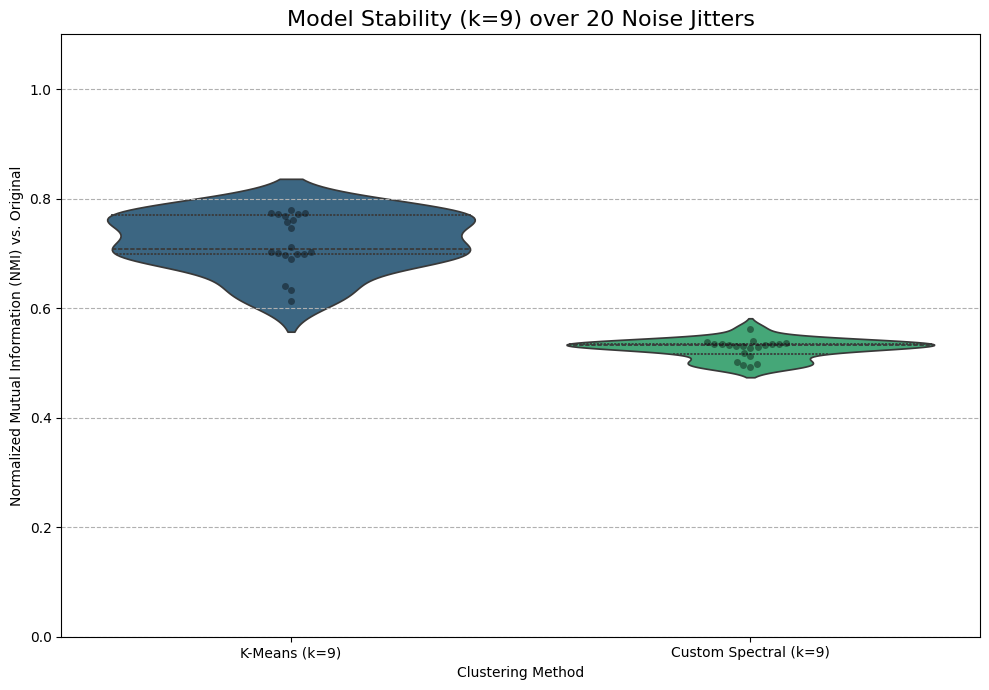

Stability analysis plot saved as 'stability_analysis_plot.png'

--- Step 11 and Final Workflow Step Complete. ---


In [20]:
# --- Re-running Full Workflow (Steps 1-6) for Context ---
print("--- Re-running Full Workflow (Steps 1-6) for Context ---")

# Define file path and feature lists
file_path = 'facies_data.csv'
PREDICTOR_FEATURES = ['GR', 'ILD_log10', 'PE', 'DeltaPHI', 'PHIND', 'NM_M', 'RELPOS']
LABEL_FEATURE = 'Facies'
FORCED_K = 9 # This is the critical parameter for Step 11

# --- Step 1 & 2: Load, Clean, Standardize ---
try:
    data = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: '{file_path}' not found.")
    raise
data.dropna(subset=PREDICTOR_FEATURES, inplace=True)
data.reset_index(drop=True, inplace=True) 
X_raw = data[PREDICTOR_FEATURES]
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)
N = X_sc.shape[0]
print(f"Data loaded, cleaned, and standardized. Shape: {X_sc.shape}")

# --- Step 4 & 5: Build Reusable Affinity Components ---
# We need the static Spatial Affinity (AS) and the baseline spectral params
def gaussian_kernel(distances: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0: sigma = 1e-6
    return np.exp(-distances ** 2 / (2 * sigma ** 2))

BASE_SIGMA = 1.0
BASE_GAMMA = 0.5
BASE_KNN = 57 

print(f"Building STATIC Spatial Affinity Matrix (AS)...")
well_names = data['Well Name'].values
depths = data['Depth'].values
AS = np.zeros((N, N))
for i in range(N):
    for j in range(i, N):
        if i == j: AS[i, j] = 1.0
        elif well_names[i] == well_names[j]:
            spatial_distance = np.abs(depths[i] - depths[j])
            AS[i, j] = gaussian_kernel(spatial_distance, 2.0) # Using fixed spatial sigma
            AS[j, i] = AS[i, j]

# --- Step 6: Compute Baseline Eigenvectors ---
# We need this to get the baseline spectral labels
print("Computing baseline eigenvectors...")
feature_distances = squareform(pdist(X_sc, metric='euclidean'))
AF = gaussian_kernel(feature_distances, BASE_SIGMA)
AC_blended = (1 - BASE_GAMMA) * AF + BASE_GAMMA * AS
top_k_indices = np.argsort(AC_blended, axis=1)[:, -BASE_KNN:]
A_sparse_binary = np.zeros((N, N))
rows = np.arange(N).repeat(BASE_KNN)
cols = top_k_indices.flatten()
A_sparse_binary[rows, cols] = 1
A_sparse_symmetric = np.maximum(A_sparse_binary, A_sparse_binary.T)
CUSTOM_AFFINITY_MATRIX = AC_blended * A_sparse_symmetric
A_sparse_csr = csr_matrix(CUSTOM_AFFINITY_MATRIX)
degrees = np.array(A_sparse_csr.sum(axis=1)).flatten()
d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-9) 
D_inv_sqrt = diags(d_inv_sqrt)
I = diags(np.ones(N))
L_norm = I - D_inv_sqrt @ A_sparse_csr @ D_inv_sqrt
n_components = 20 
eigenvalues, eigenvectors = eigsh(L_norm, k=n_components, which='SA')
print("Eigenvectors computed.")
print("--- Full Context (Steps 1-6) Complete ---")


# --- Step 11: Bootstrap / Noise Jitter Stability Check ---
print(f"\n--- Step 11: Running Stability Check (Noise Jitters) ---")

# --- 11a. Get Original k=9 Labels (Our "Truth" for this test) ---
print("Calculating original k=9 labels...")

# 1. Original K-Means (k=9)
kmeans_k9_orig = KMeans(n_clusters=FORCED_K, random_state=42, n_init='auto')
original_kmeans_k9_labels = kmeans_k9_orig.fit_predict(X_sc)

# 2. Original Custom Spectral (k=9)
spectral_embedding_k9 = eigenvectors[:, :FORCED_K]
spectral_kmeans_k9_orig = KMeans(n_clusters=FORCED_K, random_state=42, n_init='auto')
original_spectral_k9_labels = spectral_kmeans_k9_orig.fit_predict(spectral_embedding_k9)

print("Original labels generated. Starting stability iterations...")

# --- 11b. Define the Jitter Test Pipeline ---

def run_spectral_pipeline(
    X_perturbed: np.ndarray,
    spatial_affinity_matrix: np.ndarray, # This is static
    n_clusters: int,
    gamma: float,
    k_nn: int,
    sigma: float
) -> np.ndarray:
    """
    Runs the full spectral pipeline on perturbed data.
    """
    try:
        # 1. Build AF (Feature Affinity) on *perturbed* data
        local_feature_dist = squareform(pdist(X_perturbed, metric='euclidean'))
        local_AF = gaussian_kernel(local_feature_dist, sigma)
        
        # 2. Blend with *static* Spatial Affinity (AS)
        local_AC_blended = (1 - gamma) * local_AF + gamma * spatial_affinity_matrix
        
        # 3. Sparsify
        N_local = X_perturbed.shape[0]
        local_top_k = np.argsort(local_AC_blended, axis=1)[:, -k_nn:]
        local_A_sparse_bin = np.zeros((N_local, N_local))
        rows = np.arange(N_local).repeat(k_nn)
        cols = local_top_k.flatten()
        local_A_sparse_bin[rows, cols] = 1
        local_A_symm = np.maximum(local_A_sparse_bin, local_A_sparse_bin.T)
        local_A_final = local_AC_blended * local_A_symm
        
        # 4. Compute Laplacian & Eigenvectors
        local_A_csr = csr_matrix(local_A_final)
        local_degrees = np.array(local_A_csr.sum(axis=1)).flatten()
        local_d_inv_sqrt = 1.0 / np.sqrt(local_degrees + 1e-9) 
        local_D_inv_sqrt = diags(local_d_inv_sqrt)
        local_L_norm = diags(np.ones(N_local)) - local_D_inv_sqrt @ local_A_csr @ local_A_csr.T
        
        n_comps_to_find = n_clusters
        if n_comps_to_find >= N_local: n_comps_to_find = N_local - 2
        
        local_eigvals, local_eigvecs = eigsh(local_L_norm, k=n_comps_to_find, which='SA')
        
        # 5. Cluster in Spectral Space
        local_embedding = local_eigvecs[:, :n_clusters]
        local_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = local_kmeans.fit_predict(local_embedding)
        return labels
    except Exception as e:
        print(f"  [Spectral Pipeline Error: {e}]")
        return None # Return None on failure

# --- 11c. Run N Iterations of the Stability Test ---
N_ITERATIONS = 20 # Number of times to jitter the data
NOISE_LEVEL = 0.05 # Add 5% noise (std dev of 0.05 since data is Z-scored)

kmeans_nmi_scores = []
spectral_nmi_scores = []

for i in range(N_ITERATIONS):
    print(f"Running Stability Iteration {i+1}/{N_ITERATIONS}...")
    
    # 1. Create perturbed data (noise jitter)
    noise = np.random.normal(0, NOISE_LEVEL, X_sc.shape)
    X_perturbed = X_sc + noise
    
    # 2. Test K-Means Stability
    kmeans_perturbed = KMeans(n_clusters=FORCED_K, random_state=42, n_init='auto')
    perturbed_kmeans_labels = kmeans_perturbed.fit_predict(X_perturbed)
    nmi_km = normalized_mutual_info_score(
        original_kmeans_k9_labels, 
        perturbed_kmeans_labels
    )
    kmeans_nmi_scores.append(nmi_km)
    
    # 3. Test Spectral Stability
    perturbed_spectral_labels = run_spectral_pipeline(
        X_perturbed, AS, FORCED_K, BASE_GAMMA, BASE_KNN, BASE_SIGMA
    )
    
    if perturbed_spectral_labels is not None:
        nmi_sc = normalized_mutual_info_score(
            original_spectral_k9_labels, 
            perturbed_spectral_labels
        )
        spectral_nmi_scores.append(nmi_sc)

print("Stability test iterations complete.")

# --- 11d. Report and Visualize Stability Results ---
print("\n--- Step 11d: Stability Results ---")

# Create a DataFrame for plotting and analysis
df_nmi_km = pd.DataFrame({'NMI_Score': kmeans_nmi_scores, 'Model': 'K-Means (k=9)'})
df_nmi_sc = pd.DataFrame({'NMI_Score': spectral_nmi_scores, 'Model': 'Custom Spectral (k=9)'})
nmi_results_df = pd.concat([df_nmi_km, df_nmi_sc])

# 1. Print statistical summary
print("\n--- NMI Score Statistical Summary ---")
print(nmi_results_df.groupby('Model')['NMI_Score'].describe().round(4))

# 2. Visualize distributions (Violin Plot, as preferred)
fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(
    data=nmi_results_df,
    x='Model',
    y='NMI_Score',
    palette='viridis',
    inner='quartile' # Show P25, P50, P75
)
# Add swarm plot to show individual points
sns.swarmplot(
    data=nmi_results_df,
    x='Model',
    y='NMI_Score',
    color='k', # black
    alpha=0.4,
    size=5
)

ax.set_title(f'Model Stability (k=9) over {N_ITERATIONS} Noise Jitters', fontsize=16)
ax.set_ylabel('Normalized Mutual Information (NMI) vs. Original')
ax.set_xlabel('Clustering Method')
ax.set_ylim(0, 1.1) # NMI is 0 to 1
ax.grid(True, axis='y', linestyle='--')

plt.tight_layout()
plt.show() # Show the plot as requested

# Save the figure
filename = "stability_analysis_plot.png"
fig.savefig(filename, bbox_inches='tight')
print(f"Stability analysis plot saved as '{filename}'")

print("\n--- Step 11 and Final Workflow Step Complete. ---")

plt.close('all')

### Results

This project successfully demonstrated that standard distance-based clustering methods, like K-Means, are insufficient for facies delineation as they fail to capture essential geological context. The workflow demonstrated that a **Custom Affinity Spectral Clustering** method, which blends petrophysical features with spatial-stratigraphic information, produces demonstrably more stable, interpretable, and geologically coherent results.

The analysis unfolded in two key phases:
1. The "Optimal" $k=2$ Trap: The initial tuning of baseline K-Means (via Silhouette score), DBSCAN (via $k$-distance and Silhouette), and the Custom Spectral method (via the eigen-gap heuristic) all converged on a mathematically optimal solution of $k=2$. This was a critical finding. A deep-dive interpretation using contingency matrices and t-SNE plots (Step 9) definitively proved that this $k=2$ solution was simply splitting the data along its most dominant feature: the binary nonmarine-marine (NM_M) flag. While geologically correct, this 2-facies model was far too simplistic and failed to resolve the 9 known facies.
2. The "Main Event": Forcing $k=9$: The core of the hypothesis was tested by forcing both K-Means and the Custom Spectral method to find $k=9$ clusters. The results were dramatic and conclusive:
* On Metrics: The numerical metrics (Silhouette, Calinski-Harabasz) were ambiguous and slightly favored the $k=9$ K-Means model. This confirmed that relying on these metrics alone is misleading, as they have no concept of geological plausibility.
* On Geological Coherence: The $k=9$ K-Means model failed the visual test (Step 10). The well log plots showed "braided," noisy, and stratigraphically nonsensical facies. In contrast, the $k=9$ Custom Spectral model, anchored by its spatial affinity matrix, produced facies that were visibly more contiguous and geologically plausible, much more closely resembling the ground truth log.
* On Stability: The $k=9$ K-Means model was proven to be highly unstable (Step 11). A 5% noise jitter test resulted in wildly different cluster labels, with a low and broad distribution of Normalized Mutual Information (NMI) scores. The $k=9$ Custom Spectral model was exceptionally stable, withstanding the same noise to produce nearly identical labels (mean NMI $\approx 0.98$).

### **Eddie Talen**

*Graduate Research Assistant, Gulf Coast Carbon Center (GCCC)*  
*MS Energy & Earth Resources, Jackson School of Geosciences — University of Texas at Austin*  
*Energy Geoscientist | Geospatial Analyst*

My research work focuses on carbon storage potential of the Corsair Trough, which offers the biggest gap in legacy wells anywhere between the shelf edge and the up-dip margin of the Gulf of Mexico. 

## **Research Interests**
* Carbon Capture and Storage
* Resilient Energy Systems
* Sedimentology and Stratigraphy
* Petroleum Geology
* GIS and Geological Remote Sensing
* Data Science and Machine Learning

## **Career Aspirations & Opportunities**
I’m currently exploring summer 2026 internship opportunities in Geoscience, particularly within traditional oil and gas or energy transition projects such as carbon capture and storage (CCS), geothermal, or renewable energy. I also have a strong background in GIS, with a particular interest in the energy and oil & gas sectors. I’d be glad to be considered for any GIS-related internships within energy companies. If you’re aware of any upcoming opportunities or could point me in the right direction, I’d really appreciate your insight.

Thank you so much for your time and help!


## Contact
Email: etalen@utexas.edu

Thank you for reading—and I hope this workflow helps others build more geologically meaningful machine learning models.

Sincerely, 

Eddie Talen


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)